In [ ]:
import pandas as pd
from IPython.display import display
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import ast
import re
import os
import kagglehub
from kagglehub import KaggleDatasetAdapter
import zipfile
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report)

# Data Methods

In [ ]:
# load CSV files

# Hot Stuff.csv
path1 = kagglehub.dataset_download(
    "thedevastator/billboard-hot-100-audio-features",
    "Hot Stuff.csv"
)

# dataset exhibits weird behaviour where sometimes the .csv is not really a csv but a zipped file with .csv extension
# so for each dataset, check if it is zipped by reading the beginning, if so, unzip, if not, get the dataset
with open(path1, "rb") as f:
    sig = f.read(4)

if sig == b"PK\x03\x04":
    with zipfile.ZipFile(path1, "r") as z:
        inner = z.namelist()[0]
        df1 = pd.read_csv(z.open(inner), encoding="latin1", engine="python", on_bad_lines="skip")
else:
    df1 = pd.read_csv(path1, encoding="latin1", engine="python", on_bad_lines="skip")

# Hot 100 Audio Features.csv
path2 = kagglehub.dataset_download(
    "thedevastator/billboard-hot-100-audio-features",
    "Hot 100 Audio Features.csv"
)

###(OpenAI, 2025)
with open(path2, "rb") as f:
    sig = f.read(4)

if sig == b"PK\x03\x04":
    with zipfile.ZipFile(path2, "r") as z:
        inner = z.namelist()[0]
        df2 = pd.read_csv(z.open(inner), encoding="latin1", engine="python", on_bad_lines="skip")
else:
    df2 = pd.read_csv(path2, encoding="latin1", engine="python", on_bad_lines="skip")

# remove non used column
df1 = df1.drop(columns=["url", "SongID"])
df2 = df2.drop(columns=["SongID", "spotify_track_id", "spotify_track_preview_url", "spotify_track_album", "mode",])

df_final = pd.merge(
    df1,
    df2,
    left_on=["Song", "Performer"],
    right_on=["Song",      "Performer"],
    how="inner"
)

df_final = df_final.drop(columns=["index_x", "Instance", "index_y"])

100%|██████████| 10.2M/10.2M [00:00<00:00, 44.9MB/s]


Using Colab cache for faster access to the 'billboard-hot-100-audio-features' dataset.


In [ ]:
# edit data frame so that for each song/performer combination, we only keep the week the peak position of the rows

# 1) keep only rows where the weekly position equals the peak position
m = df_final["Week Position"].astype("Int64") == df_final["Peak Position"].astype("Int64")
df_eq= df_final.loc[m].copy()

# 2) decide what “later” means (pick the first date-like column that exists). In this case only WeekId exisits
date_cols = ["WeekId"]
order_col = next((c for c in date_cols if c in df_eq.columns), None)

# 3) within each (song, performer), keep the *latest* matching row
if order_col is not None:
    # ensure proper ordering
    df_eq = df_eq.sort_values(["Song", "Performer", order_col])
    result = df_eq.groupby(["Song", "Performer"], as_index=False).tail(1)
else:
    # no date column available use original row order
    result = (df_eq.reset_index()
                    .sort_values(["Song", "Performer", "index"])
                    .groupby(["Song", "Performer"], as_index=False)
                    .tail(1)
                    .drop(columns="index"))

# `result` now has one row per (song, performer), only where week_position == peak_position,


In [ ]:
# make sure none of the song/performer results are duplicated

dupe_counts = (
    result.groupby(["Song", "Performer"])
          .size()
          .reset_index(name="count")
          .query("count > 1")
          .sort_values("count", ascending=False)
)
print(dupe_counts)

# result = result.drop(columns=["spotify_genre"])

# result.head()

Empty DataFrame
Columns: [Song, Performer, count]
Index: []


In [ ]:
# check the first few rows
# print(df1.head())
# print(df2.head())

# use SQL to view the data frame
# first issue we notice is that the spotify genre column contains multiple entries

con = duckdb.connect()
con.register("result", result)

sql = """
SELECT spotify_genre
FROM result
"""
df_final_sql = con.execute(sql).df()
print(df_final_sql)


                                           spotify_genre
0                                                     []
1      ['adult standards', 'brill building pop', 'fol...
2                      ['memphis soul', 'southern soul']
3      ['classic soul', 'disco', 'funk', 'jazz funk',...
4      ['adult standards', 'disco', 'funk', 'jazz fun...
...                                                  ...
29361  ['conscious hip hop', 'north carolina hip hop'...
29362                       ['emo rap', 'miami hip hop']
29363  ['alternative r&b', 'dance pop', 'neo soul', '...
29364  ['contemporary country', 'country', 'country r...
29365                                        ['novelty']

[29366 rows x 1 columns]


In [ ]:
# the genre column has multiple different genres associates with each song. ex ['dance pop', 'pop', 'post-teen pop'], we want to change this just a single string

def first_genre(val):
    # if the column is empty/null/none, it returns NaN
    if pd.isna(val):
        return np.nan
    # real list/tuple already
    if isinstance(val, (list, tuple)):
        return val[0] if len(val) else np.nan
    # try to parse string like "['dance pop','pop']" or '["dance pop","pop"]'
    s = str(val).strip()
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (list, tuple)) and parsed:
            return parsed[0]
    except Exception:
        pass
    # if it's a comma-separated string, take the first part
    if "," in s:
        return s.split(",")[0].strip().strip("'").strip('"')
    # otherwise just return as-is
    return s

# keep original, write cleaned value to a new column
result["primary_genre"] = result["spotify_genre"].apply(first_genre)


In [ ]:
result.head()

,WeekID,Week Position,Song,Performer,Previous Week Position,Peak Position,Weeks on Chart,spotify_genre,spotify_track_duration_ms,spotify_track_explicit,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,spotify_track_popularity,primary_genre
118433,6/16/1990,54,"""B"" Girls",Young And Restless,55.0,54,7,[],242106.0,False,...,-11.913,0.439,0.0160,0.000000,0.312,0.769,193.762,3.0,20.0,[]
117072,4/28/1973,35,"""Cherry Cherry"" from Hot August Night",Neil Diamond,36.0,35,7,"['adult standards', 'brill building pop', 'fol...",443320.0,False,...,-5.061,0.137,0.0941,0.000907,0.867,0.604,172.349,4.0,16.0,adult standards
118845,11/24/1973,63,"""Having A Party"" Medley",The Ovations (Featuring Louis Williams),70.0,63,7,"['memphis soul', 'southern soul']",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,memphis soul
116632,2/2/1974,30,"""Joy"" Pt. I",Isaac Hayes,31.0,30,7,"['classic soul', 'disco', 'funk', 'jazz funk',...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,classic soul
90679,4/9/1977,57,"""Roots"" Medley",Quincy Jones,61.0,57,6,"['adult standards', 'disco', 'funk', 'jazz fun...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,adult standards


In [ ]:
# show all of the primarty genres and thier count, we will use these to normalize similar genres and see how many songs dont have a genre

con = duckdb.connect()
con.register("result", result)

sql = """
SELECT
  TRIM(BOTH ' "' FROM primary_genre) AS primary_genre,
  COUNT(*) AS count
FROM result
WHERE primary_genre IS NOT NULL AND TRIM(primary_genre) <> ''
GROUP BY 1
ORDER BY count DESC;
"""
df_counts = con.execute(sql).df()
print(df_counts)

df_counts.to_csv("primary_genre_counts.csv", index=False)

# Download the file in Colab
#from google.colab import files
#files.download("primary_genre_counts.csv")

            primary_genre  count
0         adult standards   3707
1                      []   2554
2              album rock   2317
3               dance pop   2220
4    contemporary country   1362
..                    ...    ...
670    classic danish pop      1
671             deathcore      1
672            brass band      1
673      ambient psychill      1
674               pop r&b      1

[675 rows x 2 columns]


In [ ]:
# source DataFrame

# manual mapping of primary genres to a generalized column value

# df = result


### (OpenAI, 2025)
GENRE_COL = "primary_genre" # column that contains the single primary genre string

# seed buckets
SEED_BUCKETS = {
    "electronic": [
        "edm","electronic","house","deep house","tech house","progressive house",
        "trance","techno","dubstep","future bass","drum and bass","dnb","breakbeat",
        "big room","garage","eurodance","disco","club","electro house","moombahton",
        "hardstyle","bass house","idm","uk garage","electro","ambient","downtempo"
    ],
    "hiphop": [
        "hip hop","hip-hop","rap","drill","trap","pop rap","boom bap","grime",
        "cloud rap","conscious rap","mumble rap","atl hip hop","detroit hip hop",
        "southern hip hop","chicago rap","gangsta rap","freestyle","east coast hip hop",
        "west coast hip hop","miami bass"
    ],
    "pop": [
        "pop","dance pop","bubblegum pop","brill building pop","synthpop","electropop",
        "post-teen pop","teen pop","indie pop","art pop","chamber pop","bedroom pop",
        "dream pop","power pop"
    ],
    "rnb_soul": ["r&b","rnb","contemporary r&b","neo soul","soul","motown","quiet storm"],
    "rock": [
        "rock","alternative rock","alt rock","indie rock","pop rock","punk","emo",
        "post-punk","shoegaze","grunge","hard rock","classic rock","garage rock",
        "psychedelic rock","soft rock","post-hardcore","math rock","new wave"
    ],
    "metal": [
        "metal","metalcore","death metal","black metal","nu metal","progressive metal",
        "thrash","doom metal","deathcore","sludge metal","industrial metal"
    ],
    "country": [
        "country","country pop","alt country","honky tonk","outlaw country",
        "contemporary country","americana country","cowboy western","bluegrass"
    ],
    "latin": [
        "latin","reggaeton","urbano","banda","regional mexican","mariachi","bachata",
        "salsa","merengue","cumbia","corridos","latino pop","dembow","latin trap"
    ],
    "reggae": ["reggae","dancehall","dub","roots reggae","lovers rock"],
    "jazz": ["jazz","bebop","swing","bossa nova","smooth jazz","cool jazz","vocal jazz"],
    "blues": ["blues","delta blues","chicago blues","electric blues"],
    "folk_acoustic": ["folk","indie folk","acoustic","singer-songwriter","americana","celtic"],
    "classical": ["classical","baroque","romantic","orchestral","symphony","opera","chamber"],
    "soundtrack": ["soundtrack","score","ost","broadway","show tunes","film score","game score"],
    "world": [
        "afrobeats","afro pop","afro-fusion","afrobeat","highlife","amapiano",
        "k-pop","j-pop","mandopop","c-pop","bollywood","desi","arab","turkish",
        "fado","flamenco","klezmer","bhangra"
    ],
    "adult_standards": ["adult standards","easy listening","lounge","soft adult contemporary"],
    "funk": ["funk","g funk","p funk"],
    "alternative": ["alternative","indie","alt"],
    "other": []  # fallback bucket
}

# normalization + exact-match lookup
def _norm(s: str) -> str:
    s = str(s).casefold()
    s = s.replace("&", " and ").replace("/", " ").replace("_", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

_seed_to_bucket = {
    _norm(tag): bucket
    for bucket, seeds in SEED_BUCKETS.items()
    for tag in seeds
}

# regex fallback rules (specific -> general)
###(OpenAI, 2025)
PATTERN_RULES = [
    # hiphop
    (r"\bhip\s*hop\b", "hiphop"),
    (r"\btrap\b", "hiphop"),
    (r"\brap\b", "hiphop"),
    (r"\bdrill\b", "hiphop"),
    (r"\bgrime\b", "hiphop"),
    # rnb/soul
    (r"\br\s*and\s*b\b", "rnb_soul"),
    (r"\brnb\b", "rnb_soul"),
    (r"\bsoul\b", "rnb_soul"),
    (r"\bneo\s*soul\b", "rnb_soul"),
    (r"\bmotown\b", "rnb_soul"),
    # pop
    (r"\bpost[-\s]*teen\s*pop\b", "pop"),
    (r"\bsynth\s*pop\b", "pop"),
    (r"\belectro\s*pop\b", "pop"),
    (r"\bdance\s*pop\b", "pop"),
    (r"\bpop\b", "pop"),
    # rock / metal
    (r"\bmetal(core|lic)?\b", "metal"),
    (r"\bhard\s*rock\b", "rock"),
    (r"\brock\b", "rock"),
    (r"\bpunk\b", "rock"),
    (r"\bshoegaze\b", "rock"),
    (r"\bgrunge\b", "rock"),
    (r"\bemo\b", "rock"),
    # electronic
    (r"\bedm\b", "electronic"),
    (r"\belectronic\b", "electronic"),
    (r"\b(drumn? and bass|dnb)\b", "electronic"),
    (r"\btech\s*house\b", "electronic"),
    (r"\bprogressive\s*house\b", "electronic"),
    (r"\bhouse\b", "electronic"),
    (r"\btrance\b", "electronic"),
    (r"\btechno\b", "electronic"),
    (r"\bdubstep\b", "electronic"),
    (r"\bgarage\b", "electronic"),
    (r"\b(eurodance|disco)\b", "electronic"),
    (r"\bbreakbeat\b", "electronic"),
    (r"\bfuture\s*bass\b", "electronic"),
    (r"\bmoombahton\b", "electronic"),
    (r"\bambient\b", "electronic"),
    (r"\bdowntempo\b", "electronic"),
    # latin
    (r"\blatin(o)?\b", "latin"),
    (r"\breggaeton\b", "latin"),
    (r"\burbano\b", "latin"),
    (r"\bbachata|salsa|merengue|cumbia|corridos\b", "latin"),
    # reggae
    (r"\breggae\b", "reggae"),
    (r"\bdancehall\b", "reggae"),
    (r"\bdub\b", "reggae"),
    # jazz
    (r"\bjazz\b", "jazz"),
    (r"\bbossa\s*nova\b", "jazz"),
    (r"\bswing\b", "jazz"),
    # blues
    (r"\bblues\b", "blues"),
    # folk/acoustic
    (r"\bfolk\b", "folk_acoustic"),
    (r"\bacoustic\b", "folk_acoustic"),
    (r"\bsinger[-\s]*songwriter\b", "folk_acoustic"),
    (r"\bamericana\b", "folk_acoustic"),
    (r"\bbluegrass\b", "country"),
    # country
    (r"\bcountry\b", "country"),
    # classical
    (r"\b(classical|symphony|orchestral|baroque|romantic|opera)\b", "classical"),
    # soundtrack
    (r"\b(soundtrack|score|ost|broadway|show\s*tunes|game\s*score)\b", "soundtrack"),
    # world
    (r"\bafro(beats?|[-\s]*fusion|[-\s]*pop)?\b", "world"),
    (r"\bhighlife\b", "world"),
    (r"\bamapiano\b", "world"),
    (r"\b(k|j|c|mando)[-\s]*pop\b", "world"),
    (r"\b(bollywood|desi|arab|turkish|fado|flamenco|klezmer|bhangra)\b", "world"),
    # funk
    (r"\bfunk\b", "funk"),
    # adult standards / easy listening
    (r"\b(adult\s*standards|easy\s*listening|lounge)\b", "adult_standards"),
    # alternative
    (r"\balternative\b", "alternative"),
    (r"\bindie\b", "alternative"),
    (r"\balt\b", "alternative"),
]
PATTERN_RULES = [(re.compile(p), b) for p, b in PATTERN_RULES]

# mapper
def map_bucket(genre: str) -> str:
    if pd.isna(genre) or str(genre).strip() == "":
        return "other"
    g = _norm(genre)
    if g in _seed_to_bucket:
        return _seed_to_bucket[g]
    for rx, bucket in PATTERN_RULES:
        if rx.search(g):
            return bucket
    return "other"

# create the new column on your DataFrame
result["grouped_genre"] = result[GENRE_COL].apply(map_bucket)

# # quick checks

# print(df[[GENRE_COL, "grouped genre"]].head())
# print(df["grouped genre"].value_counts(dropna=False).head(20))

# see unmapped examples to refine rules
# unmapped_examples = (
#     df.loc[df["grouped genre"] == "other", GENRE_COL]
#       .dropna()
#       .drop_duplicates()
#       .sort_values()
#       .tolist()
# )

result.head()

,WeekID,Week Position,Song,Performer,Previous Week Position,Peak Position,Weeks on Chart,spotify_genre,spotify_track_duration_ms,spotify_track_explicit,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,spotify_track_popularity,primary_genre,grouped_genre
118433,6/16/1990,54,"""B"" Girls",Young And Restless,55.0,54,7,[],242106.0,False,...,0.439,0.0160,0.000000,0.312,0.769,193.762,3.0,20.0,[],other
117072,4/28/1973,35,"""Cherry Cherry"" from Hot August Night",Neil Diamond,36.0,35,7,"['adult standards', 'brill building pop', 'fol...",443320.0,False,...,0.137,0.0941,0.000907,0.867,0.604,172.349,4.0,16.0,adult standards,adult_standards
118845,11/24/1973,63,"""Having A Party"" Medley",The Ovations (Featuring Louis Williams),70.0,63,7,"['memphis soul', 'southern soul']",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,memphis soul,rnb_soul
116632,2/2/1974,30,"""Joy"" Pt. I",Isaac Hayes,31.0,30,7,"['classic soul', 'disco', 'funk', 'jazz funk',...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,classic soul,rnb_soul
90679,4/9/1977,57,"""Roots"" Medley",Quincy Jones,61.0,57,6,"['adult standards', 'disco', 'funk', 'jazz fun...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,adult standards,adult_standards


In [ ]:
# next we want to add an additional column to the dataframe that takes the song's release week and extracts the year
# the release_year column will be used as a feature in model training

result["release_year"] = pd.to_datetime(result["WeekID"], errors="coerce") \
                           .dt.year.astype("Int64")

result.head()


,WeekID,Week Position,Song,Performer,Previous Week Position,Peak Position,Weeks on Chart,spotify_genre,spotify_track_duration_ms,spotify_track_explicit,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,spotify_track_popularity,primary_genre,grouped_genre,release_year
118433,6/16/1990,54,"""B"" Girls",Young And Restless,55.0,54,7,[],242106.0,False,...,0.0160,0.000000,0.312,0.769,193.762,3.0,20.0,[],other,1990
117072,4/28/1973,35,"""Cherry Cherry"" from Hot August Night",Neil Diamond,36.0,35,7,"['adult standards', 'brill building pop', 'fol...",443320.0,False,...,0.0941,0.000907,0.867,0.604,172.349,4.0,16.0,adult standards,adult_standards,1973
118845,11/24/1973,63,"""Having A Party"" Medley",The Ovations (Featuring Louis Williams),70.0,63,7,"['memphis soul', 'southern soul']",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,memphis soul,rnb_soul,1973
116632,2/2/1974,30,"""Joy"" Pt. I",Isaac Hayes,31.0,30,7,"['classic soul', 'disco', 'funk', 'jazz funk',...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,classic soul,rnb_soul,1974
90679,4/9/1977,57,"""Roots"" Medley",Quincy Jones,61.0,57,6,"['adult standards', 'disco', 'funk', 'jazz fun...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,adult standards,adult_standards,1977


In [ ]:
# use SQL to evaluate the performer column of the dataframe

con = duckdb.connect()
con.register("result", result)

sql = """
SELECT distinct performer
FROM result
"""

# # return ALL rows where the Performer field contains the word "featuring" (case-insensitive)
# sql = """
# SELECT performer
# FROM df
# WHERE Performer IS NOT NULL
#   AND Performer ILIKE '%featuring%'
#   or Performer ILIKE '%feat%' ;
# """
result_featuring = con.execute(sql).df()
print(result_featuring)

# save to CSV
# result_featuring.to_csv("performers.csv", index=False)
# from google.colab import files
# files.download("performers.csv")

                                         Performer
0                               Young And Restless
1                                     Neil Diamond
2          The Ovations (Featuring Louis Williams)
3                                      Isaac Hayes
4      Duane Eddy His Twangy Guitar And The Rebels
...                                            ...
10049                    KYLE Featuring Lil Yachty
10050                         J. Cole, Bas & 6LACK
10051             Kendrick Lamar Featuring MC Eiht
10052                  J. Cole, 21 Savage & Morray
10053                           J. Cole & Lil Baby

[10054 rows x 1 columns]


In [ ]:
# parse performer -> main_artist (first name before "featuring") + featured_artists (list after "featuring")
# artists were split using this script and with manual checks"

# featuring pivot (case-insensitive)
###(OpenAI, 2025)
_FEAT_RX = re.compile(r"\b(featuring|feat\.?|ft\.?)\b", flags=re.IGNORECASE)

# RIGHT side (featured): split on common delimiters incl. commas
###(OpenAI, 2025)
RIGHT_SEP_RX = re.compile(r"\s*(?:,|&|and|with|;|\+|x|×)\s*", flags=re.IGNORECASE)

# LEFT side (main): be conservative — do NOT split on commas to avoid
# names like "Tyler, The Creator". Split only on &/and/with/x/+.
###(OpenAI, 2025)
LEFT_SEP_RX = re.compile(r"\s*(?:&|and|with|\+|x|×)\s*", flags=re.IGNORECASE)

###(OpenAI, 2025)
def _dedup_preserve_order(items):
    seen = set()
    out = []
    for it in items:
        key = str(it).casefold()
        if key not in seen and it != "":
            seen.add(key)
            out.append(it)
    return out

###(OpenAI, 2025)
def _split_names(block: str, rx: re.Pattern) -> list[str]:
    if not block:
        return []
    # trim common side punctuation
    block = block.strip(" -;:|")
    parts = [p.strip(" -;:|") for p in rx.split(block) if p.strip(" -;:|")]
    return _dedup_preserve_order(parts)

###(OpenAI, 2025)
def parse_performer(perf: str) -> tuple[str, list[str]]:
    """
    Returns (main_artist_string, featured_artists_list)

    Examples:
      "Huncho Jack Featuring Offset"
        -> ("Huncho Jack", ["Offset"])
      "DJ Khaled feat. Meek Mill, J Balvin, Lil Baby & Jeremih"
        -> ("DJ Khaled", ["Meek Mill","J Balvin","Lil Baby","Jeremih"])
      "Ariana Grande & The Weeknd"
        -> ("Ariana Grande", [])   # first main only, as requested
    """
    if pd.isna(perf) or not str(perf).strip():
        return ("", [])

    s = str(perf).strip()
    m = _FEAT_RX.search(s)

    if m:
        left = s[:m.start()].strip(" -;:|")
        right = s[m.end():].strip(" -;:|")
        # main side: keep only the FIRST artist
        mains = _split_names(left, LEFT_SEP_RX)
        main_artist = mains[0] if mains else ""
        # featured side: full list
        featured = _split_names(right, RIGHT_SEP_RX)
    else:
        # no featuring marker -> take first name as main; no featured
        mains = _split_names(s, LEFT_SEP_RX)
        main_artist = mains[0] if mains else ""
        featured = []

    return (main_artist, featured)

# apply to dataframe
df = result
df[["main_artist", "featured_artists"]] = df["Performer"].apply(
    lambda t: pd.Series(parse_performer(t))
)

# check
df.head(20)


## looking at row 118845, we can see how the main_artist and featured_artists is not being parsed 100% correctly.
# we can see the main artist is "The Ovations (", when it should be "The Ovations"
# we can see the featured artist is "Louis Williams)", when it should be "Louis Williams"

,WeekID,Week Position,Song,Performer,Previous Week Position,Peak Position,Weeks on Chart,spotify_genre,spotify_track_duration_ms,spotify_track_explicit,...,liveness,valence,tempo,time_signature,spotify_track_popularity,primary_genre,grouped_genre,release_year,main_artist,featured_artists
118433,6/16/1990,54,"""B"" Girls",Young And Restless,55.0,54,7,[],242106.0,False,...,0.3120,0.769,193.762,3.0,20.0,[],other,1990,Young,[]
117072,4/28/1973,35,"""Cherry Cherry"" from Hot August Night",Neil Diamond,36.0,35,7,"['adult standards', 'brill building pop', 'fol...",443320.0,False,...,0.8670,0.604,172.349,4.0,16.0,adult standards,adult_standards,1973,Neil Diamond,[]
118845,11/24/1973,63,"""Having A Party"" Medley",The Ovations (Featuring Louis Williams),70.0,63,7,"['memphis soul', 'southern soul']",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,memphis soul,rnb_soul,1973,The Ovations (,[Louis Williams)]
116632,2/2/1974,30,"""Joy"" Pt. I",Isaac Hayes,31.0,30,7,"['classic soul', 'disco', 'funk', 'jazz funk',...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,classic soul,rnb_soul,1974,Isaac Hayes,[]
90679,4/9/1977,57,"""Roots"" Medley",Quincy Jones,61.0,57,6,"['adult standards', 'disco', 'funk', 'jazz fun...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,adult standards,adult_standards,1977,Quincy Jones,[]
100554,4/18/1959,30,"""Yep!""",Duane Eddy His Twangy Guitar And The Rebels,46.0,30,4,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,other,1959,Duane Eddy His Twangy Guitar,[]
116079,12/1/2001,23,#1,Nelly,30.0,23,7,"['dance pop', 'hip hop', 'pop', 'pop rap', 'ra...",198760.0,True,...,0.4190,0.463,89.985,4.0,50.0,dance pop,pop,2001,Nelly,[]
38708,12/2/1978,82,#1 Dee Jay,Goody Goody,84.0,82,3,['pop rap'],206106.0,False,...,0.0605,0.902,127.202,4.0,0.0,pop rap,hiphop,1978,Goody Goody,[]
120298,2/8/1975,13,#9 Dream,John Lennon,17.0,13,8,"['album rock', 'classic rock', 'folk rock', 'm...",286813.0,False,...,0.2540,0.478,115.474,4.0,55.0,album rock,rock,1975,John Lennon,[]
99717,6/15/2013,17,#Beautiful,Mariah Carey Featuring Miguel,20.0,17,4,"['dance pop', 'pop', 'r&b', 'urban contemporary']",199866.0,False,...,0.3470,0.469,107.042,4.0,56.0,dance pop,pop,2013,Mariah Carey,[Miguel]


In [ ]:
# in order to mitigate any errors within the main performer column, we manually mapped the data in the exisiting column to the correct artisit names

url = "https://raw.githubusercontent.com/faisal-jar/mse446data/main/performer_main_artist_mapping_no_notes.csv"
mapping = pd.read_csv(url)

df = result.merge(
    mapping,
    left_on="Performer",
    right_on="performer",
    how="left"
).rename(columns={"main_artist_suggested": "main_artist_single_manually_mapped"}) \
 .drop(columns=["performer"])

df.head()


,WeekID,Week Position,Song,Performer,Previous Week Position,Peak Position,Weeks on Chart,spotify_genre,spotify_track_duration_ms,spotify_track_explicit,...,valence,tempo,time_signature,spotify_track_popularity,primary_genre,grouped_genre,release_year,main_artist,featured_artists,main_artist_single_manually_mapped
0,6/16/1990,54,"""B"" Girls",Young And Restless,55.0,54,7,[],242106.0,False,...,0.769,193.762,3.0,20.0,[],other,1990,Young,[],Young And Restless
1,4/28/1973,35,"""Cherry Cherry"" from Hot August Night",Neil Diamond,36.0,35,7,"['adult standards', 'brill building pop', 'fol...",443320.0,False,...,0.604,172.349,4.0,16.0,adult standards,adult_standards,1973,Neil Diamond,[],Neil Diamond
2,11/24/1973,63,"""Having A Party"" Medley",The Ovations (Featuring Louis Williams),70.0,63,7,"['memphis soul', 'southern soul']",NaN,NaN,...,NaN,NaN,NaN,NaN,memphis soul,rnb_soul,1973,The Ovations (,[Louis Williams)],The Ovations
3,2/2/1974,30,"""Joy"" Pt. I",Isaac Hayes,31.0,30,7,"['classic soul', 'disco', 'funk', 'jazz funk',...",NaN,NaN,...,NaN,NaN,NaN,NaN,classic soul,rnb_soul,1974,Isaac Hayes,[],Isaac Hayes
4,4/9/1977,57,"""Roots"" Medley",Quincy Jones,61.0,57,6,"['adult standards', 'disco', 'funk', 'jazz fun...",NaN,NaN,...,NaN,NaN,NaN,NaN,adult standards,adult_standards,1977,Quincy Jones,[],Quincy Jones


EDA


In [ ]:
# how many unique songs are we seeing of each grouped genre

con = duckdb.connect()
con.register("df", df)

sql = """
Select
grouped_genre,
count (*)
FROM df
GROUP BY grouped_genre
"""
df_counts = con.execute(sql).df()
print(df_counts)


      grouped_genre  count_star()
0             other          6440
1          rnb_soul          1802
2            hiphop          2869
3           country          1921
4        electronic           723
5             latin           152
6        soundtrack            39
7              jazz           273
8             world            47
9         classical            33
10  adult_standards          3903
11              pop          5525
12             rock          4064
13             funk           394
14            metal           443
15            blues           267
16    folk_acoustic           263
17      alternative           114
18           reggae            94


In [ ]:
con = duckdb.connect()
con.register("df", df)

# top main artists by highest average peak position (bigger number = worse chart peak)
sql = """
SELECT
  main_artist,
  AVG("Peak Position") AS avg_peak_position,
  COUNT(*)            AS num_songs
FROM df
WHERE main_artist IS NOT NULL
  AND main_artist <> ''
  AND "Peak Position" IS NOT NULL
GROUP BY main_artist
HAVING COUNT(*) >= 25        -- adjust threshold as you like
ORDER BY num_songs Desc
LIMIT 25;                   -- show top 25
"""
avg_peak_per_main_high = con.execute(sql).df()
print(avg_peak_per_main_high)

           main_artist  avg_peak_position  num_songs
0            Glee Cast          60.320388        206
1                Drake          44.987013        154
2         Taylor Swift          41.480916        131
3        Elvis Presley          32.388889        108
4          James Brown          47.264368         87
5        Justin Bieber          52.000000         77
6               Future          66.840000         75
7          Ray Charles          51.760563         71
8      Aretha Franklin          41.859155         71
9            Lil Wayne          49.492754         69
10         The Beatles          25.304348         69
11              Eminem          43.235294         68
12          Elton John          25.258065         62
13           Ariana Gr          38.983333         60
14          Kanye West          41.661017         59
15  The Rolling Stones          28.526316         57
16             Madonna          19.571429         56
17       Stevie Wonder          30.690909     

# Data Plots

   energy_bin  avg_peak_position  num_songs
0         0.0          47.372648       6910
1         1.0          48.003871      17310


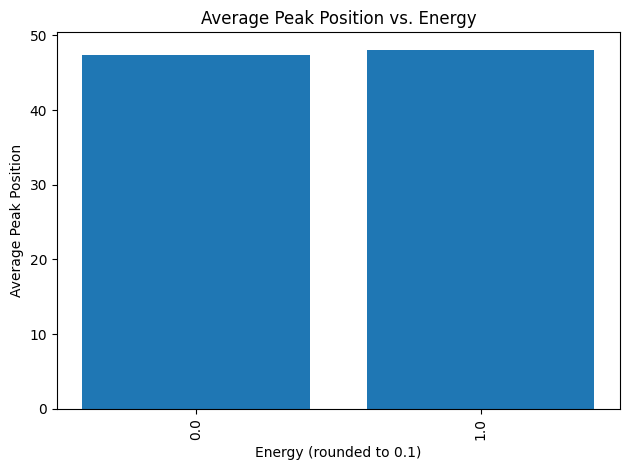

In [ ]:
con = duckdb.connect()
con.register("df", df)

sql = """
WITH base AS (
  SELECT
    "Peak Position" AS peak_pos,
    CAST(energy AS DOUBLE) AS energy
  FROM df
  WHERE energy IS NOT NULL
    AND "Peak Position" IS NOT NULL
),
binned AS (
  -- bins like 0.0, 0.1, 0.2, ...
  SELECT
    ROUND(energy, 0) AS energy_bin,
    peak_pos
  FROM base
)
SELECT
  energy_bin,
  AVG(peak_pos) AS avg_peak_position,
  COUNT(*)      AS num_songs
FROM binned
GROUP BY energy_bin
HAVING COUNT(*) >= 10      -- adjust to control noise
ORDER BY energy_bin;
"""
avg_peak_by_energy = con.execute(sql).df()
print(avg_peak_by_energy)

# Plot
plt.figure()
plt.bar(avg_peak_by_energy["energy_bin"].astype(str), avg_peak_by_energy["avg_peak_position"])
plt.xticks(rotation=90, ha="center")
plt.xlabel("Energy (rounded to 0.1)")
plt.ylabel("Average Peak Position")
plt.title("Average Peak Position vs. Energy")
plt.tight_layout()
plt.show()

   valence_bin  avg_peak_position  num_songs
0          0.0          49.417089       8286
1          1.0          46.995230      15934


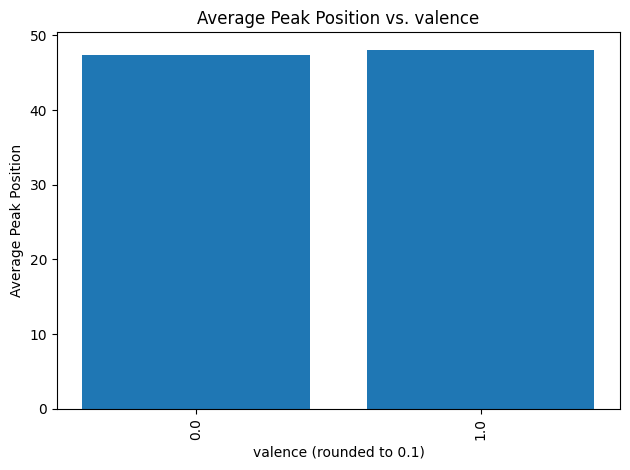

In [ ]:
con = duckdb.connect()
con.register("df", df)

sql = """
WITH base AS (
  SELECT
    "Peak Position" AS peak_pos,
    CAST(valence AS DOUBLE) AS valence
  FROM df
  WHERE valence IS NOT NULL
    AND "Peak Position" IS NOT NULL
),
binned AS (
  -- bins like 0.0, 0.1, 0.2, ...
  SELECT
    ROUND(valence, 0) AS valence_bin,
    peak_pos
  FROM base
)
SELECT
  valence_bin,
  AVG(peak_pos) AS avg_peak_position,
  COUNT(*)      AS num_songs
FROM binned
GROUP BY valence_bin
HAVING COUNT(*) >= 10      -- adjust to control noise
ORDER BY valence_bin;
"""
avg_peak_by_valence = con.execute(sql).df()
print(avg_peak_by_valence)

# Plot
plt.figure()
plt.bar(avg_peak_by_valence["valence_bin"].astype(str), avg_peak_by_energy["avg_peak_position"])
plt.xticks(rotation=90, ha="center")
plt.xlabel("valence (rounded to 0.1)")
plt.ylabel("Average Peak Position")
plt.title("Average Peak Position vs. valence")
plt.tight_layout()
plt.show()

   danceability_bin  avg_peak_position  num_songs
0               0.0          49.580762       6092
1               1.0          47.233341      18128


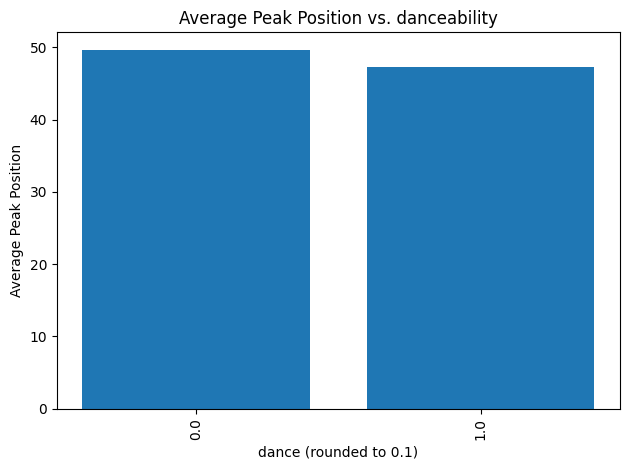

In [ ]:
con = duckdb.connect()
con.register("df", df)

sql = """
WITH base AS (
  SELECT
    "Peak Position" AS peak_pos,
    CAST(danceability AS DOUBLE) AS danceability
  FROM df
  WHERE danceability IS NOT NULL
    AND "Peak Position" IS NOT NULL
),
binned AS (
  -- bins like 0.0, 0.1, 0.2, ...
  SELECT
    ROUND(danceability, 0) AS danceability_bin,
    peak_pos
  FROM base
)
SELECT
  danceability_bin,
  AVG(peak_pos) AS avg_peak_position,
  COUNT(*)      AS num_songs
FROM binned
GROUP BY danceability_bin
HAVING COUNT(*) >= 10      -- adjust to control noise
ORDER BY danceability_bin;
"""
avg_peak_by_dance = con.execute(sql).df()
print(avg_peak_by_dance)

# Plot
plt.figure()
plt.bar(avg_peak_by_dance["danceability_bin"].astype(str), avg_peak_by_dance["avg_peak_position"])
plt.xticks(rotation=90, ha="center")
plt.xlabel("dance (rounded to 0.1)")
plt.ylabel("Average Peak Position")
plt.title("Average Peak Position vs. danceability")
plt.tight_layout()
plt.show()

    loudness_abs_db  avg_peak_position  num_songs
0                 1          53.714286         28
1                 2          52.981132        159
2                 3          49.476126        733
3                 4          50.040618       1748
4                 5          48.643342       2358
5                 6          48.668743       2729
6                 7          47.757311       2633
7                 8          47.586019       2389
8                 9          48.316092       2262
9                10          47.139942       2058
10               11          46.970952       1859
11               12          46.087186       1514
12               13          45.702419       1240
13               14          47.736111        936
14               15          46.118729        598
15               16          46.483607        366
16               17          44.333333        270
17               18          48.587302        126
18               19          48.094118         85


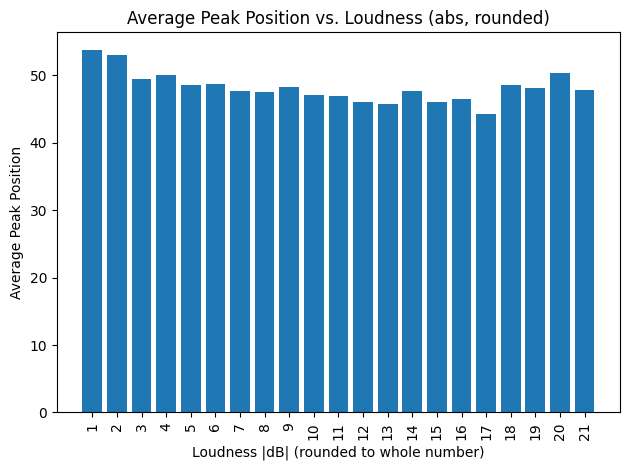

In [ ]:
con = duckdb.connect()
con.register("df", df)

# Average chart position per (rounded, positive) loudness level
# - Loudness is negative dB values; we round to nearest whole number and take ABS to make them positive.
sql = """
WITH base AS (
  SELECT
    "Peak Position" AS peak_pos,
    CAST(loudness AS DOUBLE) AS loudness
  FROM df
  WHERE loudness IS NOT NULL
    AND "Peak Position" IS NOT NULL
),
binned AS (
  SELECT
    ABS(CAST(ROUND(loudness) AS INTEGER)) AS loudness_abs_db,  -- e.g., -5.3 -> -5 -> 5
    peak_pos
  FROM base
)
SELECT
  loudness_abs_db,
  AVG(peak_pos) AS avg_peak_position,
  COUNT(*)      AS num_songs
FROM binned
GROUP BY loudness_abs_db
HAVING COUNT(*) >= 25               -- adjust threshold to taste
ORDER BY loudness_abs_db ASC;
"""

avg_peak_by_loudness = con.execute(sql).df()
print(avg_peak_by_loudness)

# Plot
plt.figure()
plt.bar(avg_peak_by_loudness["loudness_abs_db"].astype(str),
        avg_peak_by_loudness["avg_peak_position"])
plt.xticks(rotation=90, ha="center")
plt.xlabel("Loudness |dB| (rounded to whole number)")
plt.ylabel("Average Peak Position")
plt.title("Average Peak Position vs. Loudness (abs, rounded)")
plt.tight_layout()
plt.show()

    tempo_bin_start tempo_bin_label  avg_peak_position  num_songs
0                60           60-69          49.995098        204
1                70           70-79          49.337955       1154
2                80           80-89          49.763618       1946
3                90           90-99          47.120426       3006
4               100         100-109          46.484629       2895
5               110         110-119          46.809566       3366
6               120         120-129          46.863236       3751
7               130         130-139          46.832067       2632
8               140         140-149          48.847162       1832
9               150         150-159          51.446281        968
10              160         160-169          50.361927        851
11              170         170-179          48.801802        888
12              180         180-189          52.689295        383
13              190         190-199          52.360294        136
14        

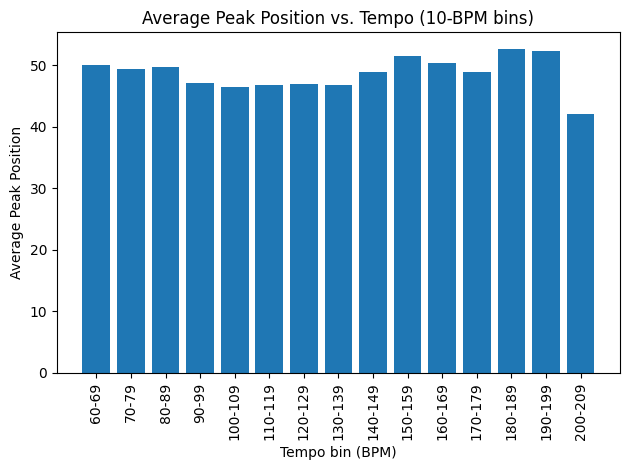

In [ ]:
con = duckdb.connect()
con.register("df", df)

# Average chart position per 10-BPM tempo bin
sql = """
WITH base AS (
  SELECT
    "Peak Position" AS peak_pos,
    CAST(tempo AS DOUBLE) AS tempo
  FROM df
  WHERE tempo IS NOT NULL
    AND "Peak Position" IS NOT NULL
),
binned AS (
  SELECT
    CAST(FLOOR(tempo / 10.0) * 10 AS INTEGER) AS tempo_bin_start,   -- e.g., 97 -> 90
    peak_pos
  FROM base
)
SELECT
  tempo_bin_start,
  CONCAT(tempo_bin_start::varchar, '-', (tempo_bin_start + 9)::varchar) AS tempo_bin_label,
  AVG(peak_pos) AS avg_peak_position,
  COUNT(*)      AS num_songs
FROM binned
GROUP BY tempo_bin_start, tempo_bin_label
HAVING COUNT(*) >= 25                 -- adjust to control noise
ORDER BY tempo_bin_start;
"""

avg_peak_by_tempo = con.execute(sql).df()
print(avg_peak_by_tempo)

# Plot
order = avg_peak_by_tempo.sort_values("tempo_bin_start")
plt.figure()
plt.bar(order["tempo_bin_label"], order["avg_peak_position"])
plt.xticks(rotation=90, ha="center")
plt.xlabel("Tempo bin (BPM)")
plt.ylabel("Average Peak Position")
plt.title("Average Peak Position vs. Tempo (10-BPM bins)")
plt.tight_layout()
plt.show()

In [ ]:
con = duckdb.connect()
con.register("df", df)

# top main artists by highest average peak position (bigger number = worse chart peak)

sql = """
SELECT
  main_artist,
  AVG("Peak Position") AS avg_peak_position,
  COUNT(*)            AS num_songs
FROM df
WHERE main_artist IS NOT NULL
  AND main_artist <> ''
  AND "Peak Position" IS NOT NULL
GROUP BY main_artist
HAVING COUNT(*) >= 25        -- adjust threshold as you like
ORDER BY avg_peak_position ASC
LIMIT 25;                   -- show top 25
"""
avg_peak_per_main_high = con.execute(sql).df()
print(avg_peak_per_main_high)

              main_artist  avg_peak_position  num_songs
0                 Madonna          19.571429         56
1              Katy Perry          20.357143         28
2         Michael Jackson          22.673913         46
3                 Rihanna          24.571429         42
4              Carpenters          24.740741         27
5              Elton John          25.258065         62
6   Daryl Hall John Oates          25.264706         34
7             The Beatles          25.304348         69
8            Phil Collins          25.880000         25
9                   Usher          27.514286         35
10            Post Malone          27.780488         41
11               Maroon 5          27.812500         32
12           Mariah Carey          28.000000         43
13     The Rolling Stones          28.526316         57
14        Whitney Houston          29.216216         37
15            Marvin Gaye          29.333333         51
16             Diana Ross          29.408163    

             genre  avg_peak_position  num_songs
0             rock          43.102362       4064
1  adult_standards          44.162952       3903
2              pop          44.928688       5525
3             funk          48.647208        394
4       electronic          50.665284        723
5           hiphop          53.591844       2869
6            metal          54.361174        443
7            other          55.095336       4846
8         rnb_soul          55.252497       1802
9          country          56.041645       1921


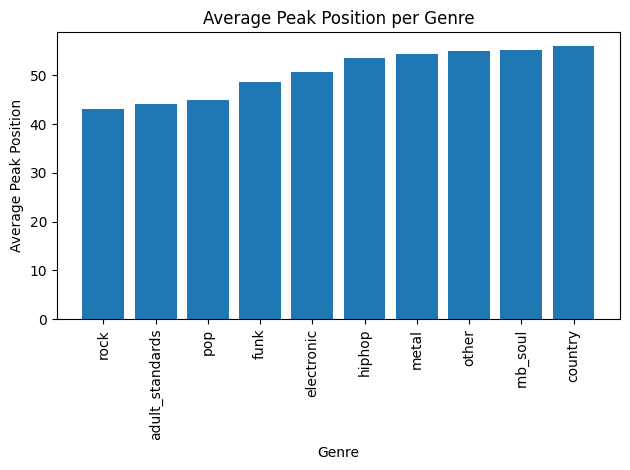

In [ ]:
# average peak position per genre

con = duckdb.connect()
con.register("df", df)

sql = """
  SELECT
    grouped_genre AS genre,
    AVG("Peak Position") AS avg_peak_position,
    COUNT(*) AS num_songs
  FROM result
  WHERE 1=1
    AND primary_genre IS NOT NULL
    AND "Peak Position" IS NOT NULL

  GROUP BY grouped_genre
  HAVING num_songs > 300
  ORDER BY avg_peak_position ASC
"""

avg_peak_per_genre = con.execute(sql).df()
print(avg_peak_per_genre)

# plot with matplotlib

order = avg_peak_per_genre.sort_values("avg_peak_position", ascending=True)
plt.figure()
plt.bar(order["genre"], order["avg_peak_position"])
plt.xticks(rotation=90, ha="center")
plt.xlabel("Genre")
plt.ylabel("Average Peak Position")
plt.title("Average Peak Position per Genre")
plt.tight_layout()
plt.show()

In [ ]:
# CONFIG
NUMERIC_FEATURES = [
    "dance_x_energy",
    "dance_x_valence",
    "acoustic_energy_interaction", # (1 - acousticness) * energy
    "tempo_deviation_120", # abs(tempo - 120)
]
CAT_FEATURES = [
    "duration_bucket",
    "release_decade",
    "spotify_track_explicit_binary",
]

# Output dir for charts
out_dir = "/mnt/data/plots"
os.makedirs(out_dir, exist_ok=True)

plt.close('all')
df_model_5 = df
con = duckdb.connect()
con.register("df", df_model_5)

# NUMERIC (decile) CHARTS
###(OpenAI, 2025)

for col in NUMERIC_FEATURES:
    if col not in df_model_5.columns:
        print(f"[skip] numeric feature not found: {col}")
        continue

    sql = f"""
    WITH base AS (
      SELECT
        CAST("Peak Position" AS DOUBLE) AS peak_pos,
        TRY_CAST({col} AS DOUBLE)       AS x
      FROM df
      WHERE "Peak Position" IS NOT NULL
    ),
    ranked AS (
      SELECT
        peak_pos, x,
        NTILE(10) OVER (ORDER BY x) AS qbin
      FROM base
      WHERE x IS NOT NULL AND isfinite(x)
    ),
    summ AS (
      SELECT
        qbin,
        MIN(x) AS bin_min,
        MAX(x) AS bin_max,
        AVG(peak_pos) AS avg_peak_position,
        COUNT(*)      AS n
      FROM ranked
      GROUP BY qbin
      ORDER BY qbin
    )
    SELECT * FROM summ;
    """
    out = con.execute(sql).df()
    if out.empty:
        print(f"[skip] no rows after filtering for {col}")
        continue

    labels = (out["bin_min"].round(0).astype(str) + "–" + out["bin_max"].round(0).astype(str))

    plt.figure()
    plt.bar(labels, out["avg_peak_position"])
    plt.xticks(rotation=90, ha="center")
    plt.xlabel(f"{col} (deciles)")
    plt.ylabel("Average Peak Position (lower is better)")
    plt.title(f"Average Peak vs. {col}")
    plt.tight_layout()
    # save + show
    filepath = os.path.join(out_dir, f"avg_peak_vs_{col}.png")
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[saved] {filepath}")

# CATEGORICAL (group-by) CHARTS
###(OpenAI, 2025)

for col in CAT_FEATURES:
    if col not in df_model_5.columns:
        print(f"[skip] categorical feature not found: {col}")
        continue

    # Coerce explicit to 0/1 if needed
    cast_expr = (
        f"CASE WHEN COALESCE(TRY_CAST({col} AS BOOLEAN), FALSE) THEN 1 ELSE 0 END"
        if col == "spotify_track_explicit_binary" else col
    )

    sql = f"""
    WITH base AS (
      SELECT
        {cast_expr} AS k,
        CAST("Peak Position" AS DOUBLE) AS peak_pos
      FROM df
      WHERE "Peak Position" IS NOT NULL
        AND {col} IS NOT NULL
    )
    SELECT
      k,
      AVG(peak_pos) AS avg_peak_position,
      COUNT(*)      AS n
    FROM base
    GROUP BY k
    ORDER BY k;
    """

    out = con.execute(sql).df()
    if out.empty:
        print(f"[skip] no rows after filtering for {col}")
        continue

    # X labels
    if col == "release_decade":
        try:
            x = out["k"].astype(int).astype(str) + "s"
        except Exception:
            x = out["k"].astype(str)
    elif col == "spotify_track_explicit_binary":
        x = out["k"].map({0: "Not Explicit", 1: "Explicit"}).fillna(out["k"].astype(str))
    else:
        x = out["k"].astype(str)

    plt.figure()
    plt.bar(x, out["avg_peak_position"])
    plt.xticks(rotation=90, ha="center")
    plt.xlabel(col)
    plt.ylabel("Average Peak Position (lower is better)")
    plt.title(f"Average Peak vs. {col}")
    plt.tight_layout()
    # save + show
    safe_col = col.replace("/", "_")
    filepath = os.path.join(out_dir, f"avg_peak_vs_{safe_col}.png")
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[saved] {filepath}")

[skip] numeric feature not found: dance_x_energy
[skip] numeric feature not found: dance_x_valence
[skip] numeric feature not found: acoustic_energy_interaction
[skip] numeric feature not found: tempo_deviation_120
[skip] categorical feature not found: duration_bucket
[skip] categorical feature not found: release_decade
[skip] categorical feature not found: spotify_track_explicit_binary


In [ ]:
con = duckdb.connect()
con.register("df", df)

BIN_DECIMALS = 0 # 0.1 bins
MIN_COUNT   = 10 # min rows per bin

###(OpenAI, 2025)
def plot_metric(name, expr, bin_decimals=None, min_count=10):
    _bin_decimals = bin_decimals if bin_decimals is not None else BIN_DECIMALS
    sql = f"""
    WITH base AS (
      SELECT "Peak Position" AS peak_pos, {expr} AS metric_val
      FROM df
      WHERE "Peak Position" IS NOT NULL
    ),
    binned AS (
      SELECT ROUND(metric_val, {_bin_decimals}) AS metric_bin, peak_pos
      FROM base
      WHERE metric_val IS NOT NULL AND isfinite(metric_val)
    )
    SELECT metric_bin, AVG(peak_pos) AS avg_peak_position, COUNT(*) AS num_songs
    FROM binned
    GROUP BY metric_bin
    HAVING COUNT(*) >= {min_count}
    ORDER BY metric_bin;
    """
    out = con.execute(sql).df()
    print(out.head())

    plt.figure(figsize=(12, 6)) # Increased figure size
    plt.bar(out["metric_bin"].astype(str), out["avg_peak_position"])
    plt.xticks(rotation=90, ha="center") # Rotated labels for better visibility
    plt.xlabel(f"{name} (rounded to {int(10**-_bin_decimals)}) Barton)")
    plt.ylabel("Average Peak Position (lower is better)")
    plt.title(f"Average Peak vs. {name}")
    plt.tight_layout()
    plt.show()

   metric_bin  avg_peak_position  num_songs
0         0.0          48.001562      18563
1         1.0          47.240410       5657


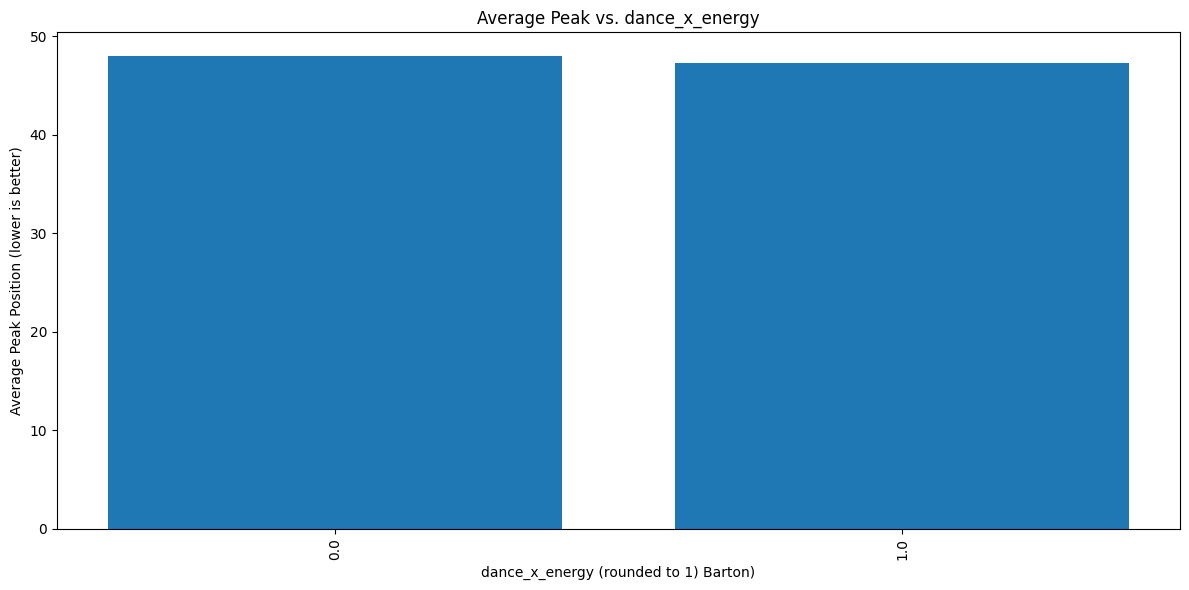

In [ ]:
plot_metric(
    "dance_x_energy",
    "CAST(danceability AS DOUBLE) * CAST(energy AS DOUBLE)"
)

   metric_bin  avg_peak_position  num_songs
0         0.0          48.809461      17398
1         1.0          45.310026       6822


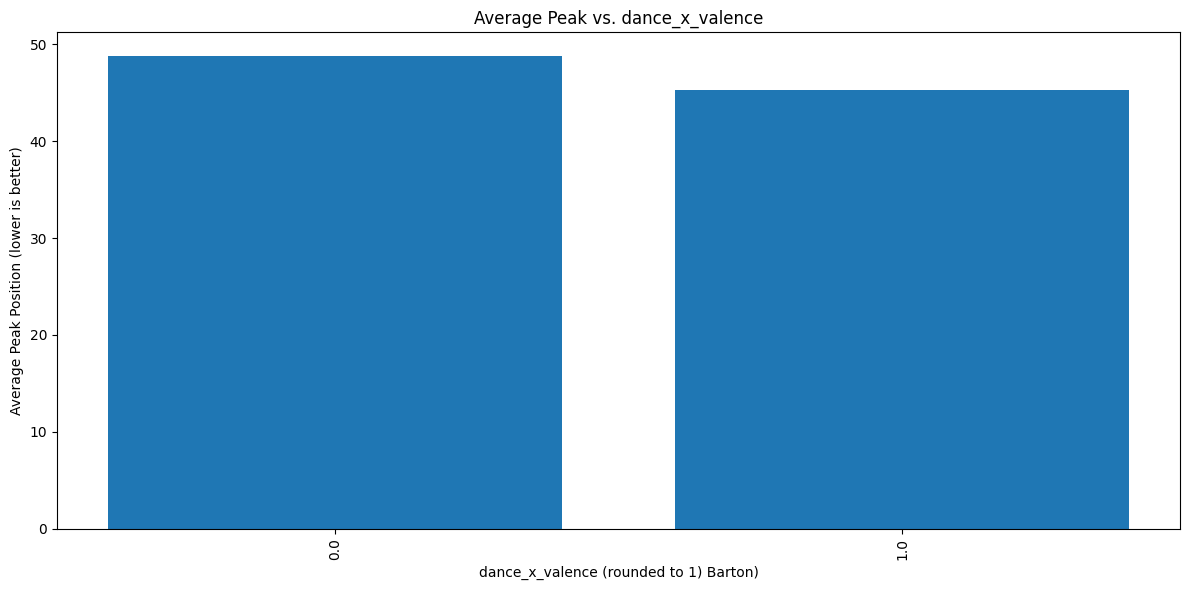

In [ ]:
plot_metric(
    "dance_x_valence",
    "CAST(danceability AS DOUBLE) * CAST(valence AS DOUBLE)"
)

   metric_bin  avg_peak_position  num_songs
0         0.0          48.842580       2217
1         1.0          47.741353       5811
2         2.0          46.636707       2648
3         3.0          47.210343       1721
4         4.0          47.291737       1186


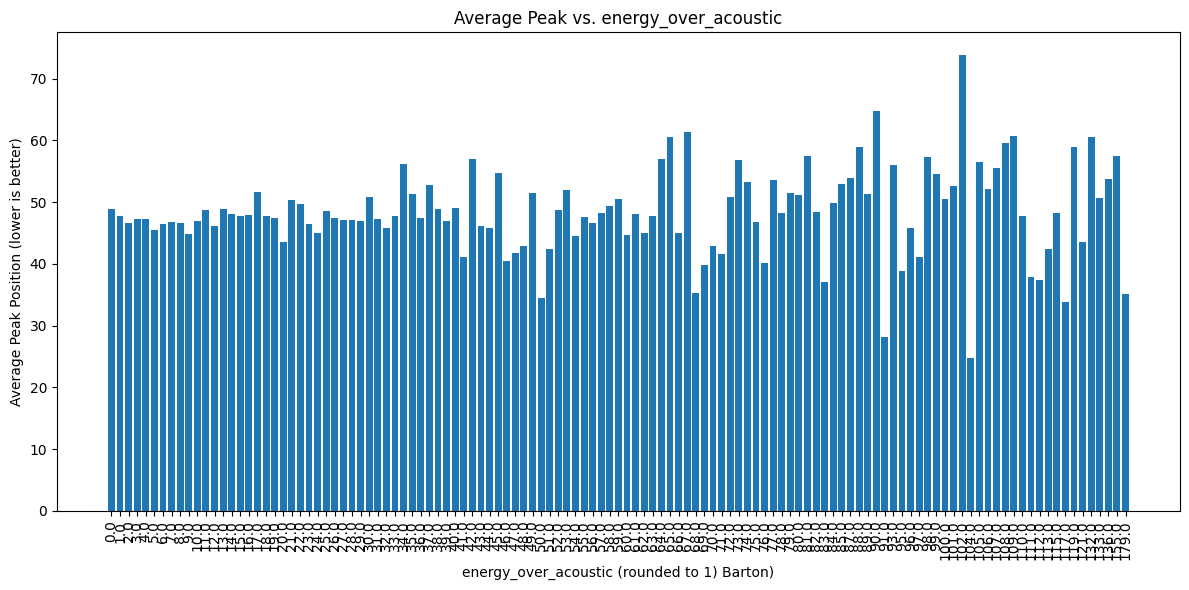

In [ ]:
plot_metric(
    "energy_over_acoustic",
    "CAST(energy AS DOUBLE) / NULLIF(CAST(acousticness AS DOUBLE), 0.0)"
)

   metric_bin  avg_peak_position  num_songs
0         0.0          47.817577      24213


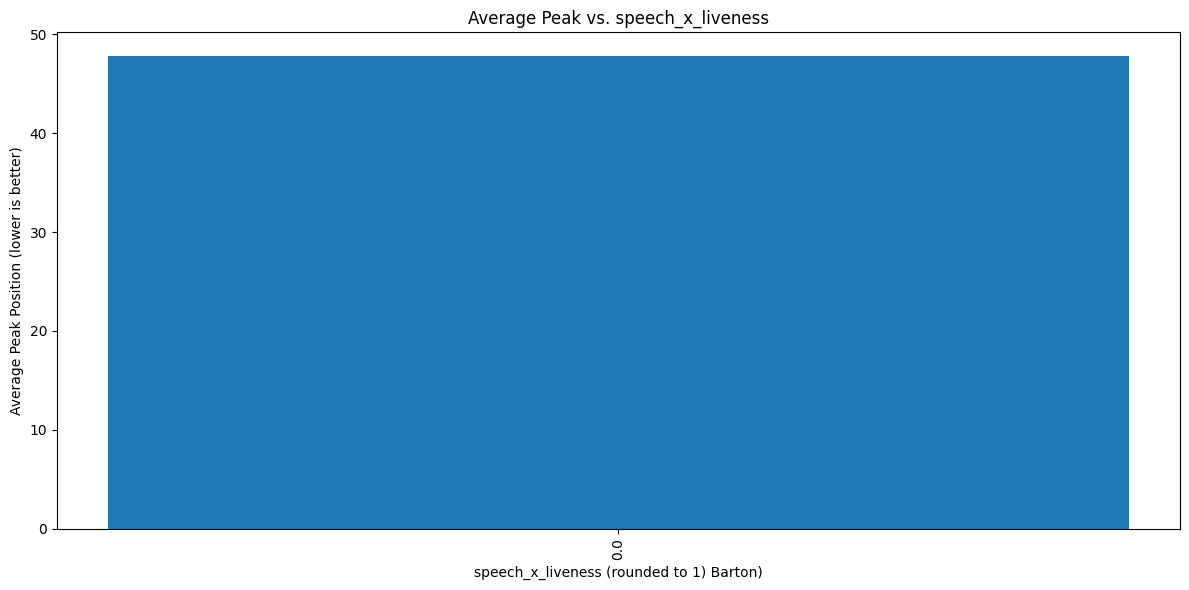

In [ ]:
plot_metric(
    "speech_x_liveness",
    "CAST(speechiness AS DOUBLE) * CAST(liveness AS DOUBLE)"
)

   metric_bin  avg_peak_position  num_songs
0         0.0          46.653974        604
1         1.0          46.915423        603
2         2.0          45.070442        724
3         3.0          46.519685        635
4         4.0          49.045649        701


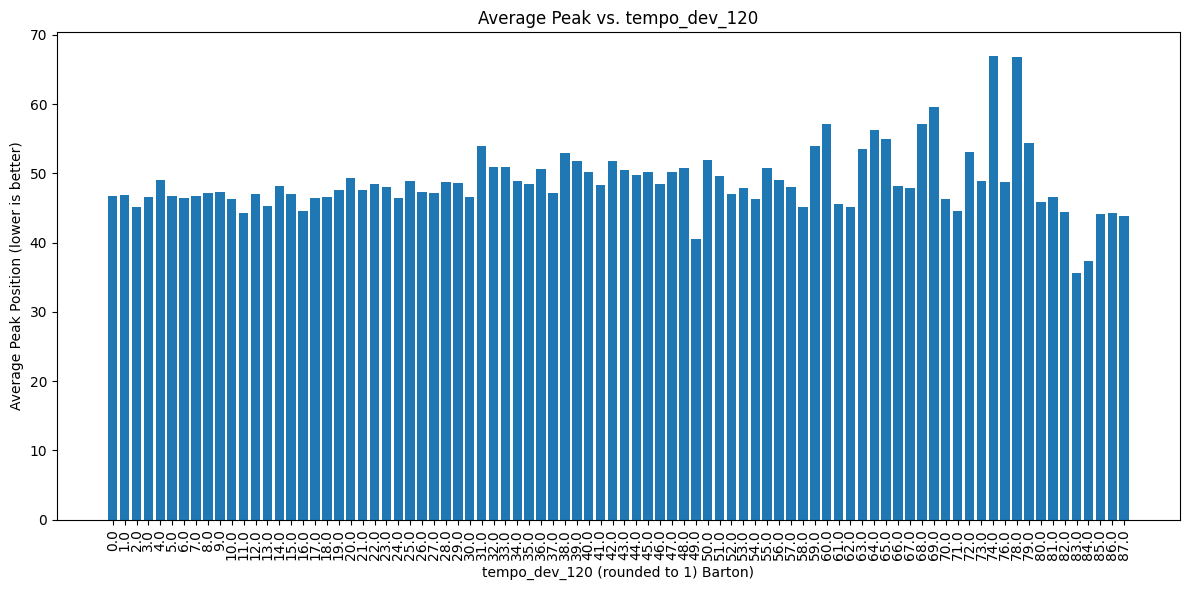

In [ ]:
plot_metric(
    "tempo_dev_120",
    "ABS(CAST(tempo AS DOUBLE) - 120.0)"
)

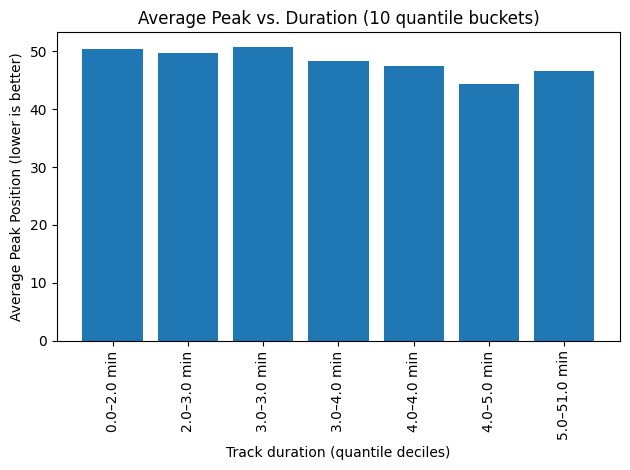

In [ ]:
sql = """
WITH base AS (
  SELECT
    "Peak Position" AS peak_pos,
    CAST(spotify_track_duration_ms AS DOUBLE) / 60000.0 AS duration_min
  FROM df
  WHERE "Peak Position" IS NOT NULL
    AND spotify_track_duration_ms IS NOT NULL
),
ranked AS (
  SELECT
    peak_pos,
    duration_min,
    NTILE(10) OVER (ORDER BY duration_min) AS qbin
  FROM base
),
summ AS (
  SELECT
    qbin,
    MIN(duration_min) AS min_dur,
    MAX(duration_min) AS max_dur,
    AVG(peak_pos)     AS avg_peak_position,
    COUNT(*)          AS num_songs
  FROM ranked
  GROUP BY qbin
  ORDER BY qbin
)
SELECT qbin, min_dur, max_dur, avg_peak_position, num_songs
FROM summ;
"""
dur_q10 = con.execute(sql).df()

labels = (dur_q10["min_dur"].round(0).astype(str)
          + "–" +
          dur_q10["max_dur"].round(0).astype(str) + " min")

plt.figure()
plt.bar(labels, dur_q10["avg_peak_position"])
plt.xticks(rotation=90, ha="center")
plt.xlabel("Track duration (quantile deciles)")
plt.ylabel("Average Peak Position (lower is better)")
plt.title("Average Peak vs. Duration (10 quantile buckets)")
plt.tight_layout()
plt.show()

   metric_bin  avg_peak_position  num_songs
0         0.0          67.214286        280
1         1.0          73.670940        234
2         2.0          69.185520        221
3         3.0          67.779167        240
4         4.0          65.572000        250


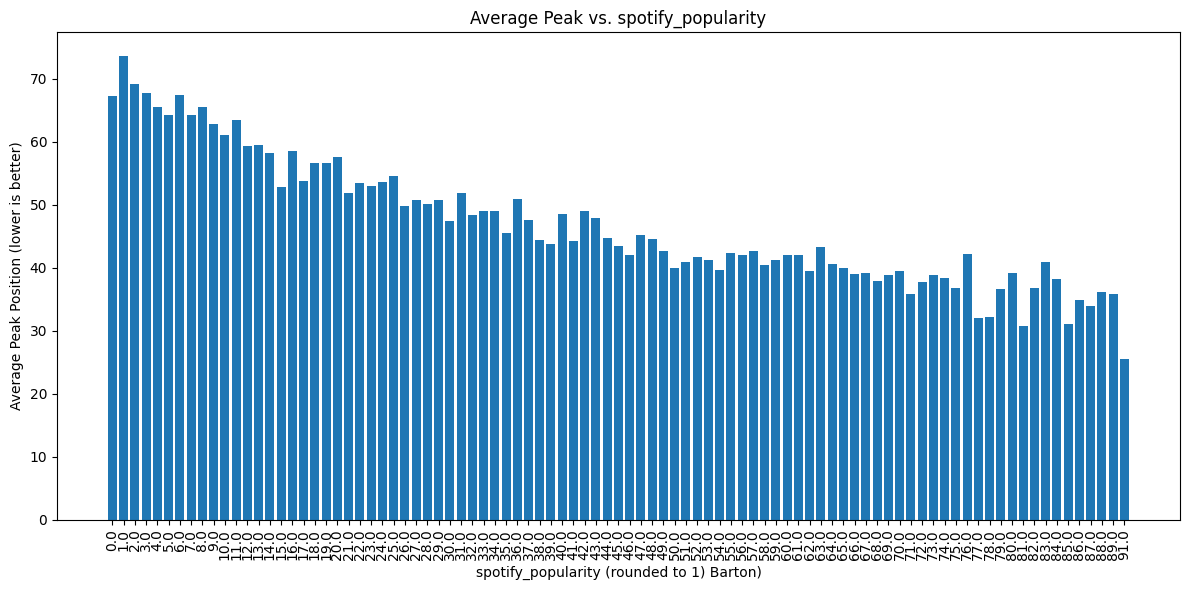

In [ ]:
plot_metric(
    "spotify_popularity",
    "CAST(spotify_track_popularity AS DOUBLE)"
)


,year,avg_peak_position,num_songs
0,1958,52.122517,302
1,1959,50.173451,565
2,1960,50.534014,588
3,1961,51.013473,668
4,1962,53.450075,671


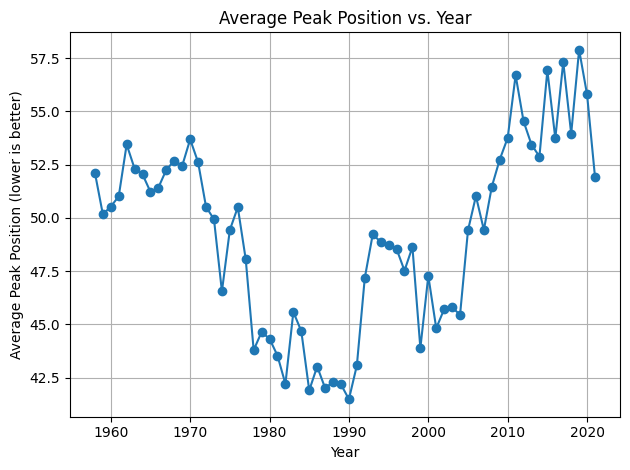

In [ ]:
sql = """
WITH base AS (
  SELECT
    CAST("Peak Position" AS DOUBLE) AS peak_pos,
    try_strptime(WeekID, '%m/%d/%Y')::DATE AS week_date  -- parse 'm/d/Y' safely
  FROM df
  WHERE "Peak Position" IS NOT NULL
),
per_year AS (
  SELECT
    EXTRACT('year' FROM week_date)::INT AS year,
    AVG(peak_pos) AS avg_peak_position,
    COUNT(*)      AS num_songs
  FROM base
  WHERE week_date IS NOT NULL
  GROUP BY year
  ORDER BY year
)
SELECT * FROM per_year;
"""

avg_peak_by_year = con.execute(sql).df()
display(avg_peak_by_year.head())

plt.figure()
plt.plot(avg_peak_by_year["year"], avg_peak_by_year["avg_peak_position"], marker="o")
plt.xlabel("Year")
plt.ylabel("Average Peak Position (lower is better)")
plt.title("Average Peak Position vs. Year")
plt.grid(True)
plt.tight_layout()
plt.show()


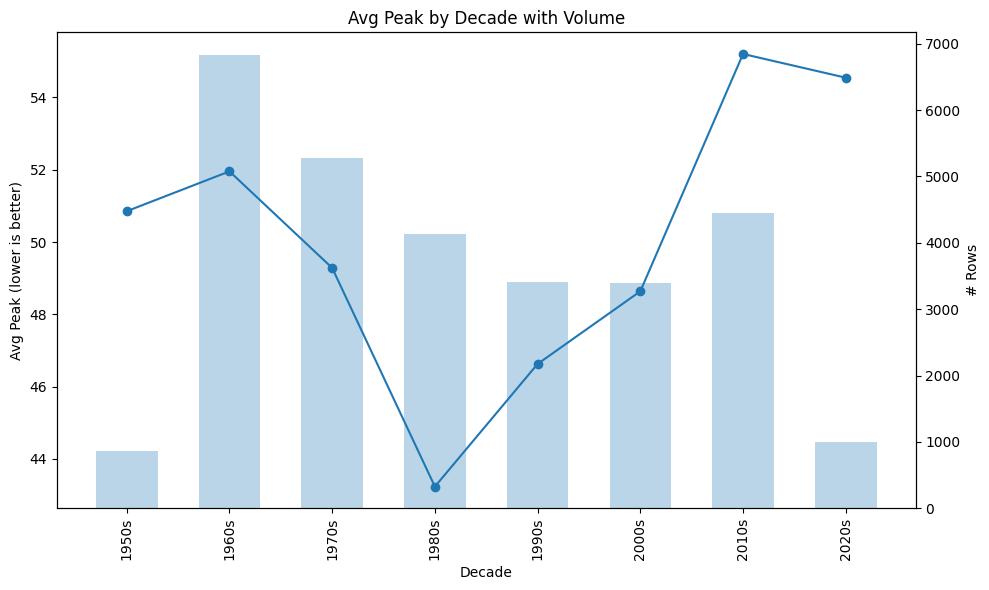

In [ ]:
MIN_COUNT = 100

sql = f"""
WITH base AS (
  SELECT
    CAST("Peak Position" AS DOUBLE) AS peak_pos,
    try_strptime(WeekID, '%m/%d/%Y')::DATE AS week_date
  FROM df
  WHERE "Peak Position" IS NOT NULL
),
with_year AS (
  SELECT
    peak_pos,
    EXTRACT('year' FROM week_date)::INT AS yr
  FROM base
  WHERE week_date IS NOT NULL
),
per_decade AS (
  SELECT
    FLOOR(yr / 10) * 10 AS decade_start,
    AVG(peak_pos) AS avg_peak_position,
    COUNT(*)      AS num_rows
  FROM with_year
  GROUP BY decade_start
)
SELECT
  decade_start,
  avg_peak_position,
  num_rows
FROM per_decade
WHERE num_rows >= {MIN_COUNT}
ORDER BY decade_start;
"""

avg_peak_by_decade = con.execute(sql).df()

# labels
avg_peak_by_decade["decade_label"] = avg_peak_by_decade["decade_start"].astype(int).astype(str) + "s"

labels = avg_peak_by_decade["decade_label"].tolist()
x = np.arange(len(labels))   # numeric positions

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Plot lines & bars using numeric positions
ax1.plot(x, avg_peak_by_decade["avg_peak_position"], marker="o")
ax2.bar(x, avg_peak_by_decade["num_rows"], alpha=0.3, width=0.6)

# Tick formatting
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=90, ha="center")

ax1.set_xlabel("Decade")
ax1.set_ylabel("Avg Peak (lower is better)")
ax2.set_ylabel("# Rows")
ax1.set_title("Avg Peak by Decade with Volume")
ax1.margins(x=0.05)

plt.tight_layout()
plt.show()

    year  unique_songs
0   1958           302
1   1959           565
2   1960           588
3   1961           668
4   1962           671
..   ...           ...
59  2017           462
60  2018           581
61  2019           525
62  2020           677
63  2021           323

[64 rows x 2 columns]


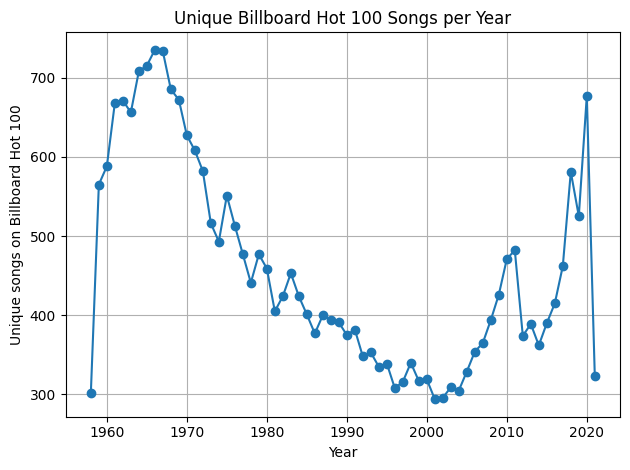

In [ ]:
# how many unique songs are we seeing each year

con = duckdb.connect()
con.register("result", result)

# SQL parse WeekID -> year, then count distinct (Song, Performer) per year
sql = """
WITH normalized AS (
  SELECT
    STRPTIME("WeekID", '%m/%d/%Y') AS week_ts,
    "Song" AS song,
    "Performer" AS performer
  FROM result
  WHERE "WeekID" IS NOT NULL
),
yearly_unique AS (
  SELECT
    EXTRACT(YEAR FROM week_ts) AS year,
    song,
    performer
  FROM normalized
  WHERE week_ts IS NOT NULL
  GROUP BY year, song, performer
)
SELECT
  year,
  COUNT(*) AS unique_songs
FROM yearly_unique
GROUP BY year
ORDER BY year
"""
songs_per_year = con.execute(sql).df()
print(songs_per_year)

# plot with matplotlib
plt.figure()
plt.plot(songs_per_year["year"], songs_per_year["unique_songs"], marker="o")
plt.xlabel("Year")
plt.ylabel("Unique songs on Billboard Hot 100")
plt.title("Unique Billboard Hot 100 Songs per Year")
plt.grid(True)
plt.tight_layout()
plt.show()



,is_explicit,avg_peak_position,num_rows,explicit_label
0,0,47.063061,21376,Not Explicit
1,1,53.651531,2907,Explicit


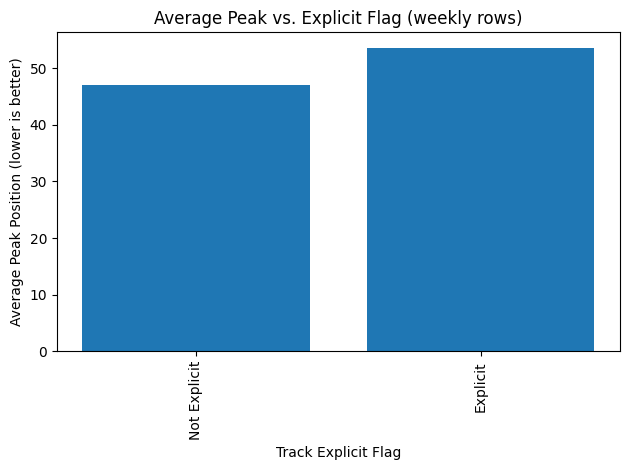

In [ ]:
sql = """
WITH base AS (
  SELECT
    CAST("Peak Position" AS DOUBLE) AS peak_pos,
    CASE
      WHEN COALESCE(TRY_CAST(spotify_track_explicit AS BOOLEAN), FALSE) THEN 1
      ELSE 0
    END AS is_explicit
  FROM df
  WHERE "Peak Position" IS NOT NULL
    AND spotify_track_explicit IS NOT NULL
)
SELECT
  is_explicit,
  AVG(peak_pos) AS avg_peak_position,
  COUNT(*)      AS num_rows
FROM base
GROUP BY is_explicit
ORDER BY is_explicit;
"""
avg_peak_by_explicit = con.execute(sql).df()
avg_peak_by_explicit["explicit_label"] = avg_peak_by_explicit["is_explicit"].map({0: "Not Explicit", 1: "Explicit"})
display(avg_peak_by_explicit)

plt.figure()
plt.bar(avg_peak_by_explicit["explicit_label"], avg_peak_by_explicit["avg_peak_position"])
plt.xlabel("Track Explicit Flag")
plt.ylabel("Average Peak Position (lower is better)")
plt.title("Average Peak vs. Explicit Flag (weekly rows)")
plt.xticks(rotation=90, ha="center")
plt.tight_layout()
plt.show()

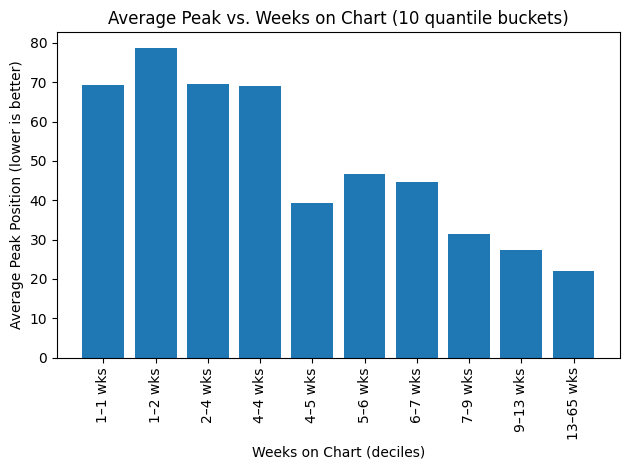

In [ ]:
# avg peak position vs weeks on chart: 10 quantile buckets
sql = """
WITH base AS (
  SELECT
    CAST("Peak Position" AS DOUBLE) AS peak_pos,
    TRY_CAST("Weeks on Chart" AS INT) AS weeks_on_chart
  FROM df
  WHERE "Peak Position" IS NOT NULL
    AND "Weeks on Chart" IS NOT NULL
),
ranked AS (
  SELECT
    peak_pos,
    weeks_on_chart,
    NTILE(10) OVER (ORDER BY weeks_on_chart) AS qbin
  FROM base
),
summ AS (
  SELECT
    qbin,
    MIN(weeks_on_chart) AS min_wks,
    MAX(weeks_on_chart) AS max_wks,
    AVG(peak_pos)       AS avg_peak_position,
    COUNT(*)            AS num_rows
  FROM ranked
  GROUP BY qbin
  ORDER BY qbin
)
SELECT qbin, min_wks, max_wks, avg_peak_position, num_rows
FROM summ;
"""
woc_q10 = con.execute(sql).df()

labels = (woc_q10["min_wks"].astype(int).astype(str)
          + "–" +
          woc_q10["max_wks"].astype(int).astype(str) + " wks")

plt.figure()
plt.bar(labels, woc_q10["avg_peak_position"])
plt.xticks(rotation=90, ha="center")
plt.xlabel("Weeks on Chart (deciles)")
plt.ylabel("Average Peak Position (lower is better)")
plt.title("Average Peak vs. Weeks on Chart (10 quantile buckets)")
plt.tight_layout()
plt.show()

      WeekID  Week Position                  Song                 Performer  \
0   8/7/2010              1  Love The Way You Lie  Eminem Featuring Rihanna   
1  1/11/2014              1           The Monster  Eminem Featuring Rihanna   

   Previous Week Position  Peak Position  Weeks on Chart  \
0                     1.0              1               5   
1                     1.0              1               9   

                                     spotify_genre  spotify_track_duration_ms  \
0  ['detroit hip hop', 'g funk', 'hip hop', 'rap']                   263373.0   
1  ['detroit hip hop', 'g funk', 'hip hop', 'rap']                   250188.0   

   spotify_track_explicit  ...  liveness  valence    tempo  time_signature  \
0                    True  ...      0.52    0.641   86.989             4.0   
1                    True  ...      0.12    0.624  110.049             4.0   

   spotify_track_popularity    primary_genre  grouped_genre  release_year  \
0                      83

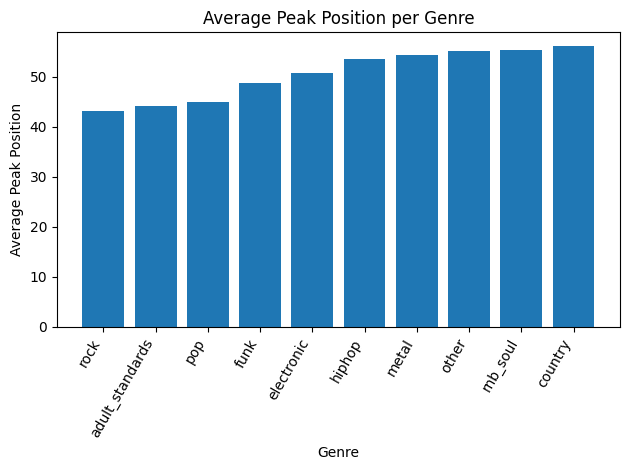

In [ ]:
# average peak position per performer

con = duckdb.connect()
con.register("result", result)

sql = """
  SELECT
     Performer,
    AVG("Peak Position") AS avg_peak_position,
    COUNT(*) AS num_songs
  FROM result
  WHERE 1=1
    AND primary_genre IS NOT NULL
    AND "Peak Position" IS NOT NULL
    AND primary_genre NOT in ('[]')
  GROUP BY Performer
  HAVING num_songs > 1
  ORDER BY avg_peak_position ASC
"""

sql = """
  SELECT
     *
  FROM result
  WHERE 1=1
    AND Performer = 'Eminem Featuring Rihanna'
"""

avg_peak_per_performer = con.execute(sql).df()
print(avg_peak_per_performer)


order = avg_peak_per_genre.sort_values("avg_peak_position", ascending=True)
plt.figure()
plt.bar(order["genre"], order["avg_peak_position"])
plt.xticks(rotation=60, ha="right")
plt.xlabel("Genre")
plt.ylabel("Average Peak Position")
plt.title("Average Peak Position per Genre")
plt.tight_layout()
plt.show()



# Model Generation

In [ ]:
# ensure that all the used numerical and categorical features in the dataframe are not null

numeric_features = [
    "spotify_track_duration_ms","danceability","energy","key","loudness","speechiness",
    "acousticness","instrumentalness","liveness","valence","tempo","time_signature",
    "spotify_track_popularity", "release_year"
]
categorical_features = ["grouped_genre","main_artist"]

feature_cols = numeric_features + categorical_features

# treat empty strings in categoricals as NaN
df[categorical_features] = df[categorical_features].apply(
    lambda s: s.replace(r"^\s*$", np.nan, regex=True)
)

# drop rows with any nulls across the selected columns
df = df.dropna(subset=feature_cols).copy()

In [ ]:
# multinomial logistic regression setup (one-vs-rest)

# first, setup conversion of 'peak' chart position to class 1, 2, 3
# if position 1-10, class 3, if 11-50, class 2, if 51-100, class 1

def peak_to_class1(peak):

  try:
    pos = int(peak) # try to get int of peak position from data
  except Exception:
    return np.nan

  # classify class based on peak position:
  if 1 <= pos <= 10:
    return 3
  elif 11 <= pos <= 50:
    return 2
  elif 51 <= pos <= 100:
    return 1
  else:
    return np.nan # if weird result or > 100, don't work with it

# add class column for each entry in df:
df1 = df.copy()
df1["chart_class"] = df1["Peak Position"].apply(peak_to_class1)

# only keep songs that have a valid class label, store in new df used for model:
df_model = df1[df1["chart_class"].notna()].copy()
df_model["chart_class"] = df_model["chart_class"].astype(int)
df_model["chart_class"].value_counts().sort_index()

# check model df
df_model.head()

,WeekID,Week Position,Song,Performer,Previous Week Position,Peak Position,Weeks on Chart,spotify_genre,spotify_track_duration_ms,spotify_track_explicit,...,tempo,time_signature,spotify_track_popularity,primary_genre,grouped_genre,release_year,main_artist,featured_artists,main_artist_single_manually_mapped,chart_class
0,6/16/1990,54,"""B"" Girls",Young And Restless,55.0,54,7,[],242106.0,False,...,193.762,3.0,20.0,[],other,1990,Young,[],Young And Restless,1
1,4/28/1973,35,"""Cherry Cherry"" from Hot August Night",Neil Diamond,36.0,35,7,"['adult standards', 'brill building pop', 'fol...",443320.0,False,...,172.349,4.0,16.0,adult standards,adult_standards,1973,Neil Diamond,[],Neil Diamond,2
6,12/1/2001,23,#1,Nelly,30.0,23,7,"['dance pop', 'hip hop', 'pop', 'pop rap', 'ra...",198760.0,True,...,89.985,4.0,50.0,dance pop,pop,2001,Nelly,[],Nelly,2
7,12/2/1978,82,#1 Dee Jay,Goody Goody,84.0,82,3,['pop rap'],206106.0,False,...,127.202,4.0,0.0,pop rap,hiphop,1978,Goody Goody,[],Goody Goody,1
8,2/8/1975,13,#9 Dream,John Lennon,17.0,13,8,"['album rock', 'classic rock', 'folk rock', 'm...",286813.0,False,...,115.474,4.0,55.0,album rock,rock,1975,John Lennon,[],John Lennon,2


In [ ]:
# try with 4 evenly balanced classes

# multinomial logistic regression setup (one-vs-rest)

# first, setup conversion of 'peak' chart position to class 1, 2, 3,4
# if position 1-25, class 4, if 26-50, class 3, if 51-75 class 2, 76-100 class 1

def peak_to_class2(peak):

  try:
    pos = int(peak) # try to get int of peak position from data
  except Exception:
    return np.nan

  # classify class based on peak position:
  if 1 <= pos <= 25:
    return 4
  elif 26 <= pos <= 50:
    return 3
  elif 51 <= pos <= 75:
    return 2
  elif 76 <= pos <= 100:
    return 1
  else:
    return np.nan # if weird result or > 100, don't work with it

# add class column for each entry in df:
df2 = df.copy()
df2["chart_class"] = df2["Peak Position"].apply(peak_to_class2)

# only keep songs that have a valid class label, store in new df used for model:
df_model_2 = df2[df2["chart_class"].notna()].copy()
df_model_2["chart_class"] = df_model_2["chart_class"].astype(int)
df_model_2["chart_class"].value_counts().sort_index()

# check model df
df_model_2.head()

,WeekID,Week Position,Song,Performer,Previous Week Position,Peak Position,Weeks on Chart,spotify_genre,spotify_track_duration_ms,spotify_track_explicit,...,tempo,time_signature,spotify_track_popularity,primary_genre,grouped_genre,release_year,main_artist,featured_artists,main_artist_single_manually_mapped,chart_class
0,6/16/1990,54,"""B"" Girls",Young And Restless,55.0,54,7,[],242106.0,False,...,193.762,3.0,20.0,[],other,1990,Young,[],Young And Restless,2
1,4/28/1973,35,"""Cherry Cherry"" from Hot August Night",Neil Diamond,36.0,35,7,"['adult standards', 'brill building pop', 'fol...",443320.0,False,...,172.349,4.0,16.0,adult standards,adult_standards,1973,Neil Diamond,[],Neil Diamond,3
6,12/1/2001,23,#1,Nelly,30.0,23,7,"['dance pop', 'hip hop', 'pop', 'pop rap', 'ra...",198760.0,True,...,89.985,4.0,50.0,dance pop,pop,2001,Nelly,[],Nelly,4
7,12/2/1978,82,#1 Dee Jay,Goody Goody,84.0,82,3,['pop rap'],206106.0,False,...,127.202,4.0,0.0,pop rap,hiphop,1978,Goody Goody,[],Goody Goody,1
8,2/8/1975,13,#9 Dream,John Lennon,17.0,13,8,"['album rock', 'classic rock', 'folk rock', 'm...",286813.0,False,...,115.474,4.0,55.0,album rock,rock,1975,John Lennon,[],John Lennon,4


In [ ]:
# try sematic buckets

def peak_to_class3(peak):
    try:
        p = int(peak)
    except Exception:
        return np.nan

    if   1 <= p <= 5:
      return 4 # elite
    elif 6 <= p <= 20:
      return 3 # top
    elif 21 <= p <= 50:
      return 2 # mid
    elif 51 <= p <= 100:
      return 1 # tail
    else:
      return np.nan

# add class column
df3 = df.copy()
df3["chart_class"] = df3["Peak Position"].apply(peak_to_class3)

# keep valid labels for modeling
df_model_3 = df3[df3["chart_class"].notna()].copy()
df_model_3["chart_class"] = df_model_3["chart_class"].astype(int)

print(df_model_3["chart_class"].value_counts().sort_index())
df_model_3.head()

chart_class
1    11089
2     7253
3     3924
4     1950
Name: count, dtype: int64


,WeekID,Week Position,Song,Performer,Previous Week Position,Peak Position,Weeks on Chart,spotify_genre,spotify_track_duration_ms,spotify_track_explicit,...,tempo,time_signature,spotify_track_popularity,primary_genre,grouped_genre,release_year,main_artist,featured_artists,main_artist_single_manually_mapped,chart_class
0,6/16/1990,54,"""B"" Girls",Young And Restless,55.0,54,7,[],242106.0,False,...,193.762,3.0,20.0,[],other,1990,Young,[],Young And Restless,1
1,4/28/1973,35,"""Cherry Cherry"" from Hot August Night",Neil Diamond,36.0,35,7,"['adult standards', 'brill building pop', 'fol...",443320.0,False,...,172.349,4.0,16.0,adult standards,adult_standards,1973,Neil Diamond,[],Neil Diamond,2
6,12/1/2001,23,#1,Nelly,30.0,23,7,"['dance pop', 'hip hop', 'pop', 'pop rap', 'ra...",198760.0,True,...,89.985,4.0,50.0,dance pop,pop,2001,Nelly,[],Nelly,2
7,12/2/1978,82,#1 Dee Jay,Goody Goody,84.0,82,3,['pop rap'],206106.0,False,...,127.202,4.0,0.0,pop rap,hiphop,1978,Goody Goody,[],Goody Goody,1
8,2/8/1975,13,#9 Dream,John Lennon,17.0,13,8,"['album rock', 'classic rock', 'folk rock', 'm...",286813.0,False,...,115.474,4.0,55.0,album rock,rock,1975,John Lennon,[],John Lennon,3


In [ ]:
# try hybrid split

def peak_to_class4(peak):

  try:
    pos = int(peak) # try to get int of peak position from data
  except Exception:
    return np.nan

  # classify class based on peak position:
  if 1 <= pos <= 5:
    return 3
  elif 6 <= pos <= 40:
    return 2
  elif 41 <= pos <= 100:
    return 1
  else:
    return np.nan # if weird result or > 100, don't work with it

# add class column for each entry in df:
df4 = df.copy()
df4["chart_class"] = df4["Peak Position"].apply(peak_to_class4)

# only keep songs that have a valid class label, store in new df used for model:
df_model_4 = df4[df4["chart_class"].notna()].copy()
df_model_4["chart_class"] = df_model_4["chart_class"].astype(int)
df_model_4["chart_class"].value_counts().sort_index()

# check model df
df_model_4.head()

,WeekID,Week Position,Song,Performer,Previous Week Position,Peak Position,Weeks on Chart,spotify_genre,spotify_track_duration_ms,spotify_track_explicit,...,tempo,time_signature,spotify_track_popularity,primary_genre,grouped_genre,release_year,main_artist,featured_artists,main_artist_single_manually_mapped,chart_class
0,6/16/1990,54,"""B"" Girls",Young And Restless,55.0,54,7,[],242106.0,False,...,193.762,3.0,20.0,[],other,1990,Young,[],Young And Restless,1
1,4/28/1973,35,"""Cherry Cherry"" from Hot August Night",Neil Diamond,36.0,35,7,"['adult standards', 'brill building pop', 'fol...",443320.0,False,...,172.349,4.0,16.0,adult standards,adult_standards,1973,Neil Diamond,[],Neil Diamond,2
6,12/1/2001,23,#1,Nelly,30.0,23,7,"['dance pop', 'hip hop', 'pop', 'pop rap', 'ra...",198760.0,True,...,89.985,4.0,50.0,dance pop,pop,2001,Nelly,[],Nelly,2
7,12/2/1978,82,#1 Dee Jay,Goody Goody,84.0,82,3,['pop rap'],206106.0,False,...,127.202,4.0,0.0,pop rap,hiphop,1978,Goody Goody,[],Goody Goody,1
8,2/8/1975,13,#9 Dream,John Lennon,17.0,13,8,"['album rock', 'classic rock', 'folk rock', 'm...",286813.0,False,...,115.474,4.0,55.0,album rock,rock,1975,John Lennon,[],John Lennon,2


In [ ]:
# choosing feature columns to use to train the model
# choosing not to include weeks on chart or previous position as to not have the model lean on these values that give away the prediciton

numeric_features = [
    "spotify_track_duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
    "spotify_track_popularity",
    "release_year"
]

categorical_features = [
    "grouped_genre",
    "main_artist_single_manually_mapped",
]

# defne target and features total
target = "chart_class"
features = numeric_features + categorical_features

# store clean data
data1 = df_model[features + [target]].dropna()
data2 = df_model_2[features + [target]].dropna()
data3 = df_model_3[features + [target]].dropna()
data4 = df_model_4[features + [target]].dropna()

# define variables
X1 = data1[features]
y1 = data1[target].astype(int)

X2 = data2[features]
y2 = data2[target].astype(int)

X3 = data3[features]
y3 = data3[target].astype(int)

X4 = data4[features]
y4 = data4[target].astype(int)

In [ ]:
# preprocessing & logistic regression

# preprocess for numeric cols:
numeric_trans = Pipeline(steps=[("scaler", StandardScaler())]) # this will apply StandardScaler() to numeric cols
# when .fit() -> compute mean & stdev per numeric feature, when .transform() -> standardizes

# preprocess for categorical cols:
categorical_trans = OneHotEncoder(handle_unknown="ignore") # one hot encode cat features
# ignore unseen cats

# combine w col transformer:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_trans, numeric_features), # apply numeric transformer ^ to numeric features
        ("cat", categorical_trans, categorical_features) # apply cat transformer ^ to cat features
    ]
)

# logistic regression classifier:
logistic = OneVsRestClassifier(LogisticRegression(solver="lbfgs", max_iter=1000))

# model defn:
base_model = Pipeline(steps=[("preprocess", preprocess), ("clf", logistic)]) # first preprocess/transform features, then fit logistic reg.

# Model Evaluation

In [ ]:
# evaluation:
# 80/20 train/test split

# 20% test size, 80% training data
# stratify=y -> test set should keep same class proportions as original data (class 1,2,3)
# no randomness fo rreproducability
result1 = train_test_split(X1, y1, test_size=0.2, stratify=y1, random_state=0)
result2 = train_test_split(X2, y2, test_size=0.2, stratify=y2, random_state=0)
result3 = train_test_split(X3, y3, test_size=0.2, stratify=y3, random_state=0)
result4 = train_test_split(X4, y4, test_size=0.2, stratify=y4, random_state=0)

# defn split result outputs:
X1_train = result1[0]
X1_test = result1[1]
y1_train = result1[2]
y1_test = result1[3]

X2_train = result2[0]
X2_test = result2[1]
y2_train = result2[2]
y2_test = result2[3]

X3_train = result3[0]
X3_test = result3[1]
y3_train = result3[2]
y3_test = result3[3]

X4_train = result4[0]
X4_test = result4[1]
y4_train = result4[2]
y4_test = result4[3]

# setup 5-fold cross validation:
cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
# shuffle rows to prevent biases
# no randomness

# split training into 5 folds, trains model on 4 folds and tests accuracy on remaining fold
cross_val_scores1 = cross_val_score(base_model, X1_train, y1_train, cv=cross_val, scoring="accuracy")
cross_val_scores2 = cross_val_score(base_model, X2_train, y2_train, cv=cross_val, scoring="accuracy")
cross_val_scores3 = cross_val_score(base_model, X3_train, y3_train, cv=cross_val, scoring="accuracy")
cross_val_scores4 = cross_val_score(base_model, X4_train, y4_train, cv=cross_val, scoring="accuracy")


print("5-fold cross val accuracy (model 1): {:.4f} +- {:.3f}".format(cross_val_scores1.mean(), cross_val_scores1.std()))
print("5-fold cross val accuracy (model 2): {:.4f} +- {:.3f}".format(cross_val_scores2.mean(), cross_val_scores2.std()))
print("5-fold cross val accuracy (model 3): {:.4f} +- {:.3f}".format(cross_val_scores3.mean(), cross_val_scores3.std()))
print("5-fold cross val accuracy (model 4): {:.4f} +- {:.3f}".format(cross_val_scores4.mean(), cross_val_scores4.std()))

5-fold cross val accuracy (model 1): 0.5748 +- 0.008
5-fold cross val accuracy (model 2): 0.4297 +- 0.004
5-fold cross val accuracy (model 3): 0.5115 +- 0.003
5-fold cross val accuracy (model 4): 0.6507 +- 0.006


In [ ]:
# try random forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_clf = RandomForestClassifier(
    n_estimators=300, # number of trees
    max_depth=None, # let trees grow fully
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=0, # reproducible
    n_jobs=-1
)

# build RF pipeline: same preprocessing, different classifier
rf_model = Pipeline(steps=[("preprocess", preprocess), ("clf", rf_clf)])

In [ ]:
# RF cross validation

# 5-fold cross validation for random forest
rf_cv_scores1 = cross_val_score(rf_model, X1_train, y1_train, cv=cross_val, scoring="accuracy")
rf_cv_scores2 = cross_val_score(rf_model, X2_train, y2_train, cv=cross_val, scoring="accuracy")
rf_cv_scores3 = cross_val_score(rf_model, X3_train, y3_train, cv=cross_val, scoring="accuracy")
rf_cv_scores4 = cross_val_score(rf_model, X4_train, y4_train, cv=cross_val, scoring="accuracy")

print("RF 5-fold CV accuracy (model 1): {:.4f} +- {:.3f}".format(rf_cv_scores1.mean(), rf_cv_scores1.std()))
print("RF 5-fold CV accuracy (model 2): {:.4f} +- {:.3f}".format(rf_cv_scores2.mean(), rf_cv_scores2.std()))
print("RF 5-fold CV accuracy (model 3): {:.4f} +- {:.3f}".format(rf_cv_scores3.mean(), rf_cv_scores3.std()))
print("RF 5-fold CV accuracy (model 4): {:.4f} +- {:.3f}".format(rf_cv_scores4.mean(), rf_cv_scores4.std()))

RF 5-fold CV accuracy (model 1): 0.5645 +- 0.006
RF 5-fold CV accuracy (model 1): 0.4230 +- 0.005
RF 5-fold CV accuracy (model 1): 0.5006 +- 0.004
RF 5-fold CV accuracy (model 1): 0.6359 +- 0.008


In [ ]:
from sklearn.base import clone

model1 = clone(base_model).fit(X1_train, y1_train) # split 1
model2 = clone(base_model).fit(X2_train, y2_train) # split 2
model3 = clone(base_model).fit(X3_train, y3_train) # split 3
model4 = clone(base_model).fit(X4_train, y4_train) # split 4

In [ ]:
# metrics

y1_pred = model1.predict(X1_test)
y2_pred = model2.predict(X2_test)
y3_pred = model3.predict(X3_test)
y4_pred = model4.predict(X4_test)

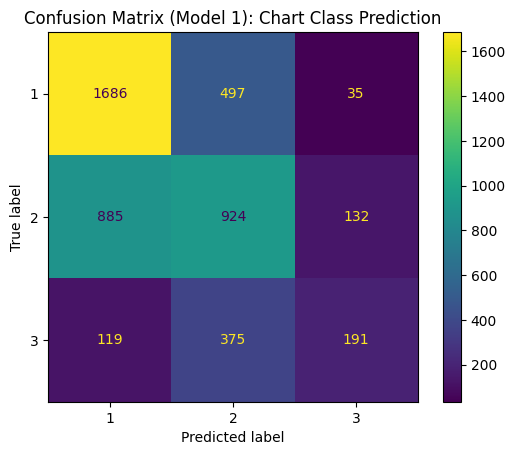

In [ ]:
# confusion matrix (model 1)

labels = sorted(y1.unique().tolist()) # sort class vals

conf_m = confusion_matrix(y1_test, y1_pred, labels=labels) # use test and predicted vals
display = ConfusionMatrixDisplay(confusion_matrix=conf_m, display_labels=labels)
display.plot(values_format="d")
plt.title("Confusion Matrix (Model 1): Chart Class Prediction")
plt.show()

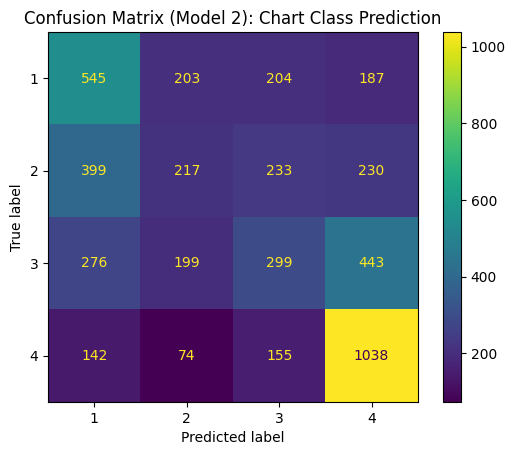

In [ ]:
# confusion matrix (model 2)

labels = sorted(y2.unique().tolist()) # sort class vals

conf_m = confusion_matrix(y2_test, y2_pred, labels=labels) # use test and predicted vals
display = ConfusionMatrixDisplay(confusion_matrix=conf_m, display_labels=labels)
display.plot(values_format="d")
plt.title("Confusion Matrix (Model 2): Chart Class Prediction")
plt.show()

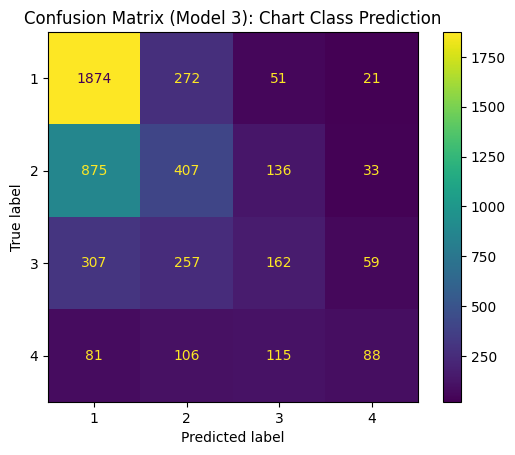

In [ ]:
# confusion matrix (model 3)

labels = sorted(y3.unique().tolist()) # sort class vals

conf_m = confusion_matrix(y3_test, y3_pred, labels=labels) # use test and predicted vals
display = ConfusionMatrixDisplay(confusion_matrix=conf_m, display_labels=labels)
display.plot(values_format="d")
plt.title("Confusion Matrix (Model 3): Chart Class Prediction")
plt.show()

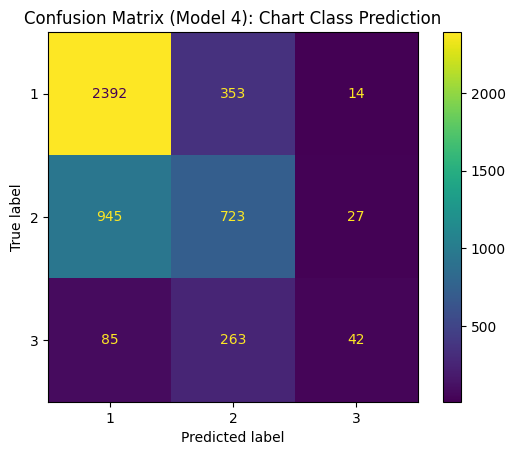

In [ ]:
# confusion matrix (model 4)

labels = sorted(y4.unique().tolist()) # sort class vals

conf_m = confusion_matrix(y4_test, y4_pred, labels=labels) # use test and predicted vals
display = ConfusionMatrixDisplay(confusion_matrix=conf_m, display_labels=labels)
display.plot(values_format="d")
plt.title("Confusion Matrix (Model 4): Chart Class Prediction")
plt.show()

In [ ]:
# coefficient interpretation function
###(OpenAI, 2025)

def interpret_coef(fitted, split, num_feats, cat_feats, class_names):
  print(f"Coefficient interpretation for: {split}")

  clf = fitted.named_steps["clf"] # fitted classifier from model pipeline
  pre = fitted.named_steps["preprocess"]

  feature_names = pre.get_feature_names_out()
  feature_names = np.array([str(n) for n in feature_names]) # combined feature name array


  valid_i = []
  for i, name in enumerate(feature_names):
    if "main_artist" not in name.lower():
      valid_i.append(i)

  coef = np.vstack([est.coef_.ravel() for est in clf.estimators_])
  classes = clf.classes_

  # loop over classes by index & label
  for i, label in enumerate(classes):
    class_name = class_names.get(label, str(label))

    print(f"\nClass {label} ({class_name})")

    # take non-artist coefs from this class only
    full_row = coef[i]
    row = full_row[valid_i]
    names = feature_names[valid_i]

    # sorted indicies
    sorted_idx = np.argsort(row)

    # noticed problem where main artist coef dominates and cannot read other coefficient impacts
    # thus, main artist will not be printed

    print("\nFeatures that INCREASE odds of this class:")
    # loop through indices in reverse order (largest first) for most pos
    printed = 0
    for i in reversed(sorted_idx):
      name = feature_names[i]
      if "main_artist" in name.lower():
        continue
      print(f"{feature_names[i]:40s} {row[i]: .3f}")
      printed += 1
      if printed >= 10:
        break

    print("\nFeatures that DECREASE odds of this class:")
    printed = 0
    # loop through indices in order (smallest first) for most neg
    for i in sorted_idx:
      name = feature_names[i]
      if "main_artist" in name.lower():
        continue
      print(f"{feature_names[i]:40s} {row[i]: .3f}")
      printed += 1
      if printed >= 10:
        break

In [ ]:
# defn labels for each split for coef interpretation
split1_labels = {1: "51-100", 2: "11-50", 3: "1-10"}
split2_labels = {1: "76-100", 2: "51-75", 3: "26-50", 4: "1-25"}
split3_labels = {1: "51-100", 2: "21-50", 3: "6-50", 4: "1-5"}
split4_labels = {1: "41-100", 2: "6-40", 3: "1-5"}

# run interpretation
interpret_coef(fitted=model1, split="Model 1", num_feats=numeric_features, cat_feats=categorical_features, class_names=split1_labels)
interpret_coef(fitted=model2, split="Model 2", num_feats=numeric_features, cat_feats=categorical_features, class_names=split2_labels)
interpret_coef(fitted=model3, split="Model 3", num_feats=numeric_features, cat_feats=categorical_features, class_names=split3_labels)
interpret_coef(fitted=model4, split="Model 4", num_feats=numeric_features, cat_feats=categorical_features, class_names=split4_labels)

Coefficient interpretation for: Model 1

Class 1 (51-100)

Features that INCREASE odds of this class:
num__release_year                         1.282
cat__grouped_genre_latin                  0.863
cat__grouped_genre_metal                  0.660
cat__grouped_genre_world                  0.604
cat__grouped_genre_blues                  0.460
cat__grouped_genre_alternative            0.230
cat__grouped_genre_rnb_soul               0.210
cat__grouped_genre_reggae                 0.185
cat__grouped_genre_hiphop                 0.136
num__acousticness                         0.125

Features that DECREASE odds of this class:
num__spotify_track_popularity            -1.492
cat__grouped_genre_soundtrack            -0.732
cat__grouped_genre_other                 -0.584
cat__grouped_genre_adult_standards       -0.472
cat__grouped_genre_pop                   -0.464
cat__grouped_genre_classical             -0.337
cat__grouped_genre_folk_acoustic         -0.328
cat__grouped_genre_country            

# Best Model Attempt 1

In [ ]:
df_model_5 = df_model_4.copy()

# parse date and build a song-level table (one row per song)
df_model_5["WeekID_dt"] = pd.to_datetime(df_model_5["WeekID"], errors="coerce")

song_level = (df_model_5.groupby(["Song", "Performer", "main_artist_single_manually_mapped"], as_index=False).agg(
        first_week=("WeekID_dt","min"),
        min_peak=("Peak Position","min") # the song's best chart position
    )
)

# sort by artist & time, compute prior stats
song_level = song_level.sort_values(["main_artist_single_manually_mapped","first_week","Song"])

# prior distinct songs that have charted
song_level["prior_song_count"] = (song_level.groupby("main_artist_single_manually_mapped").cumcount()) # 0, 1, 2, ... gives count of earlier songs for that artist

# prior top 10 count (and other useful priors)
song_level["is_top10"] = (song_level["min_peak"] <= 10).astype(int)
song_level["prior_top10_count"] = (song_level.groupby("main_artist_single_manually_mapped")["is_top10"].cumsum().shift(fill_value=0))

# prior best (min) peak so far
song_level["prior_best_peak"] = (song_level.groupby("main_artist_single_manually_mapped")["min_peak"].expanding().min().reset_index(level=0, drop=True).shift(fill_value=np.nan))

# prior average peak so far
song_level["prior_avg_peak"] = (song_level.groupby("main_artist_single_manually_mapped")["min_peak"].expanding().mean().reset_index(level=0, drop=True).shift(fill_value=np.nan))

# merge these "prior" features back to df
df_model_5 = df_model_5.merge(song_level[["Song","Performer","prior_song_count","prior_top10_count","prior_best_peak","prior_avg_peak"]],
    on=["Song","Performer"],
    how="left"
)

# check
df_model_5.head()

,WeekID,Week Position,Song,Performer,Previous Week Position,Peak Position,Weeks on Chart,spotify_genre,spotify_track_duration_ms,spotify_track_explicit,...,release_year,main_artist,featured_artists,main_artist_single_manually_mapped,chart_class,WeekID_dt,prior_song_count,prior_top10_count,prior_best_peak,prior_avg_peak
0,6/16/1990,54,"""B"" Girls",Young And Restless,55.0,54,7,[],242106.0,False,...,1990,Young,[],Young And Restless,1,1990-06-16,0,0,29.0,29.000000
1,4/28/1973,35,"""Cherry Cherry"" from Hot August Night",Neil Diamond,36.0,35,7,"['adult standards', 'brill building pop', 'fol...",443320.0,False,...,1973,Neil Diamond,[],Neil Diamond,2,1973-04-28,21,3,1.0,28.952381
2,12/1/2001,23,#1,Nelly,30.0,23,7,"['dance pop', 'hip hop', 'pop', 'pop rap', 'ra...",198760.0,True,...,2001,Nelly,[],Nelly,2,2001-12-01,2,1,3.0,9.500000
3,12/2/1978,82,#1 Dee Jay,Goody Goody,84.0,82,3,['pop rap'],206106.0,False,...,1978,Goody Goody,[],Goody Goody,1,1978-12-02,0,0,39.0,62.500000
4,2/8/1975,13,#9 Dream,John Lennon,17.0,13,8,"['album rock', 'classic rock', 'folk rock', 'm...",286813.0,False,...,1975,John Lennon,[],John Lennon,2,1975-02-08,1,0,24.0,24.000000


In [ ]:
# choosing new feature columns to use to train the model, including "prior" features

numeric_features1 = [
    "spotify_track_duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
    "spotify_track_popularity",
    "release_year",
    "prior_song_count",
    "prior_top10_count",
    "prior_best_peak",
    "prior_avg_peak"
]

categorical_features1 = [
    "grouped_genre",
    "main_artist_single_manually_mapped"
]

# defne target and features total
target = "chart_class"
features = numeric_features1 + categorical_features1
# store clean data
data5 = df_model_5[features + [target]].dropna()

# define variables
X5 = data5[features]
y5 = data5[target].astype(int)

In [ ]:
# re-preprocessing & logistic regression (new features)

# preprocess for numeric cols:
numeric_trans = Pipeline(steps=[("scaler", StandardScaler())]) # this will apply StandardScaler() to numeric cols
# when .fit() -> compute mean & stdev per numeric feature, when .transform() -> standardizes

# preprocess for categorical cols:
categorical_trans = OneHotEncoder(handle_unknown="ignore") # one hot encode cat features
# ignore unseen cats

# combine w col transformer:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_trans, numeric_features1), # apply numeric transformer ^ to numeric features
        ("cat", categorical_trans, categorical_features1) # apply cat transformer ^ to cat features
    ]
)

# logistic regression classifier:
logistic = OneVsRestClassifier(LogisticRegression(solver="lbfgs", max_iter=1000))

# model defn:
model5 = Pipeline(steps=[("preprocess", preprocess), ("clf", logistic)]) # first preprocess/transform features, then fit logistic reg.

In [ ]:
# evaluation:
# 80/20 train/test split

result5 = train_test_split(X5, y5, test_size=0.2, stratify=y5, random_state=0)
# 20% test size, 80% training data
# stratify=y -> test set should keep same class proportions as original data (class 1,2,3)
# no randomness fo rreproducability

# defn split result outputs:
X5_train = result5[0]
X5_test = result5[1]
y5_train = result5[2]
y5_test = result5[3]

# setup 5-fold cross validation:
cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
# shuffle rows to prevent biases
# no randomness

cross_val_scores5 = cross_val_score(model5, X5_train, y5_train, cv=cross_val, scoring="accuracy")
# split training into 5 folds, trains model on 4 folds and tests accuracy on remaining fold

print("5-fold cross val accuracy (model 5): {:.4f} +- {:.3f}".format(cross_val_scores5.mean(), cross_val_scores5.std()))

5-fold cross val accuracy (model 5): 0.6508 +- 0.008


In [ ]:
model5.fit(X5_train, y5_train) # model 5 with diff feats

# metric
y5_pred = model5.predict(X5_test)

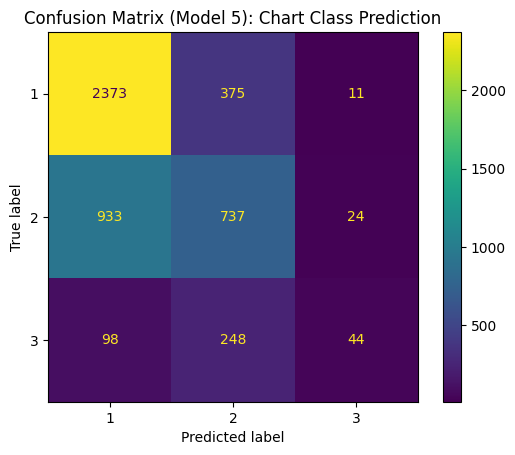

In [ ]:
# confusion matrix (model 5)

labels = sorted(y5.unique().tolist()) # sort class vals

conf_m = confusion_matrix(y5_test, y5_pred, labels=labels) # use test and predicted vals
display = ConfusionMatrixDisplay(confusion_matrix=conf_m, display_labels=labels)
display.plot(values_format="d")
plt.title("Confusion Matrix (Model 5): Chart Class Prediction")
plt.show()

In [ ]:
# coefficient interpretation (model 5)

interpret_coef(fitted=model5, split="Model 5", num_feats=numeric_features1, cat_feats=categorical_features1, class_names=split4_labels) # uses same split as model 4

Coefficient interpretation for: Model 5

Class 1 (41-100)

Features that INCREASE odds of this class:
num__release_year                         1.366
cat__grouped_genre_latin                  0.757
cat__grouped_genre_world                  0.716
cat__grouped_genre_metal                  0.540
cat__grouped_genre_blues                  0.345
cat__grouped_genre_reggae                 0.265
cat__grouped_genre_classical              0.205
cat__grouped_genre_jazz                   0.128
num__prior_avg_peak                       0.123
cat__grouped_genre_alternative            0.111

Features that DECREASE odds of this class:
num__spotify_track_popularity            -1.643
cat__grouped_genre_other                 -0.759
cat__grouped_genre_adult_standards       -0.615
cat__grouped_genre_soundtrack            -0.601
cat__grouped_genre_pop                   -0.601
cat__grouped_genre_folk_acoustic         -0.401
num__danceability                        -0.152
num__prior_top10_count                

In [ ]:
# random forest

rf_cv_scores5 = cross_val_score(rf_model, X5_train, y5_train, cv=cross_val, scoring="accuracy")

print("RF 5-fold CV accuracy (model 1): {:.4f} +- {:.3f}".format(rf_cv_scores5.mean(), rf_cv_scores5.std()))

RF 5-fold CV accuracy (model 1): 0.6364 +- 0.005


# Best Model Attempt 2

Try Again: Model 6

We need better features, so try:

numeric_features = [
    "spotify_track_duration_ms",
    "release_decade",
    danceability * energy,
    -danceability * valence,
    (1 - acousticness) * energy,
    "loudness",
    abs(temp-120),
    "acousticness",
    "spotify_track_popularity",
    "prior_best_peak",
    "prior_avg_peak",
    "key",
    "time_signature"

]

categorical_features = [
    "grouped_genre",
    "main_artist_single_manually_mapped",
    genre_by_decade
]

# Engineered Features

In [ ]:
df_model_6 = df_model_5.copy()
df_model_6["dance_x_energy"] = df_model_6["danceability"] * df_model_6["energy"]
df_model_6["dance_x_valence"] = df_model_6["danceability"] * df_model_6["valence"]
df_model_6["acoustic_energy_interaction"] = (1 - df_model_6["acousticness"]) * df_model_6["energy"]
df_model_6["tempo_deviation_120"] = abs(df_model_6["tempo"] - 120)

# bucketing spotify_track_duration_ms into 10 quantiles
df_model_6['duration_bucket'] = pd.qcut(df_model_6['spotify_track_duration_ms'], q=10, labels=False, duplicates='drop')

# converting release_year to release_decade
df_model_6['release_decade'] = (df_model_6['release_year'] // 10) * 10

# converting spotify_track_explicit to 0s and 1s
df_model_6['spotify_track_explicit_binary'] = df_model_6['spotify_track_explicit'].astype(int)

# concatenating grouped_genre and release_decade
df_model_6['genre_decade_interaction'] = df_model_6['grouped_genre'].astype(str) + '_' + df_model_6['release_decade'].astype(str)

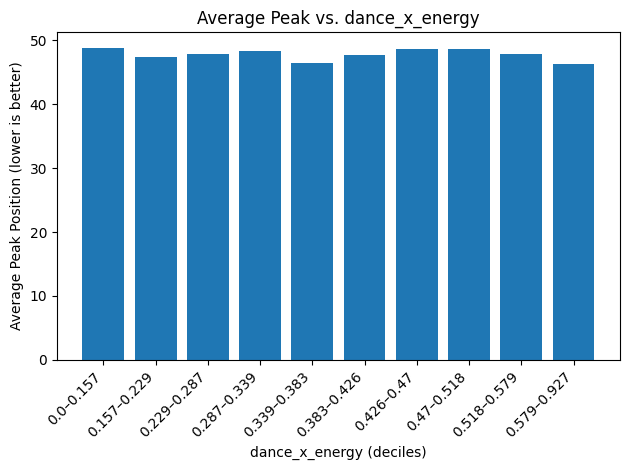

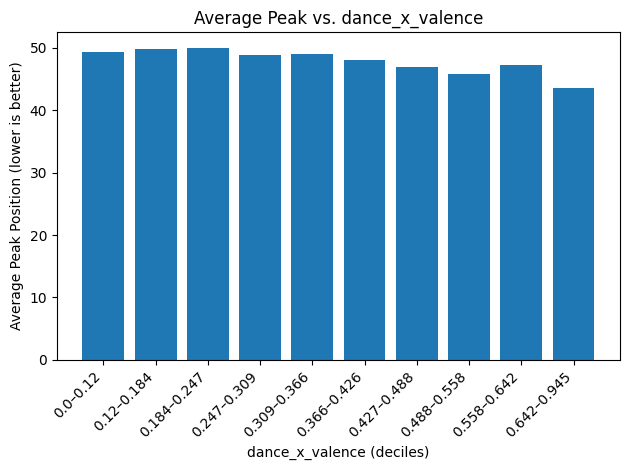

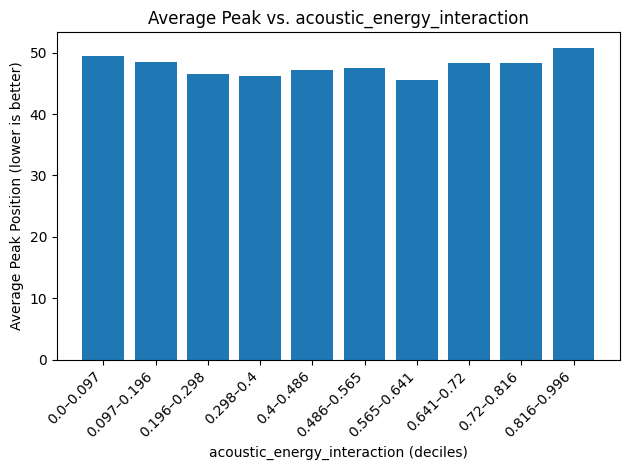

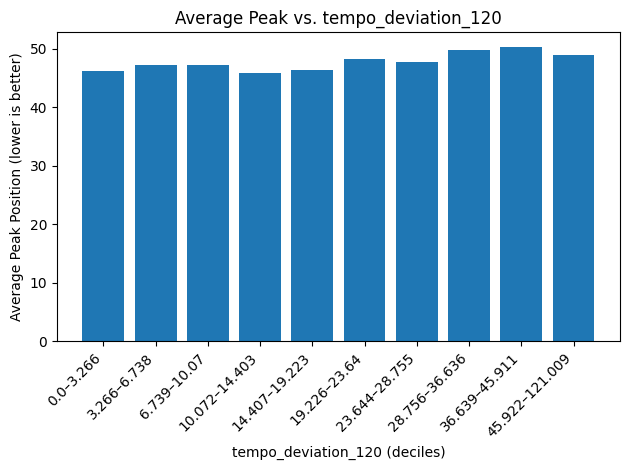

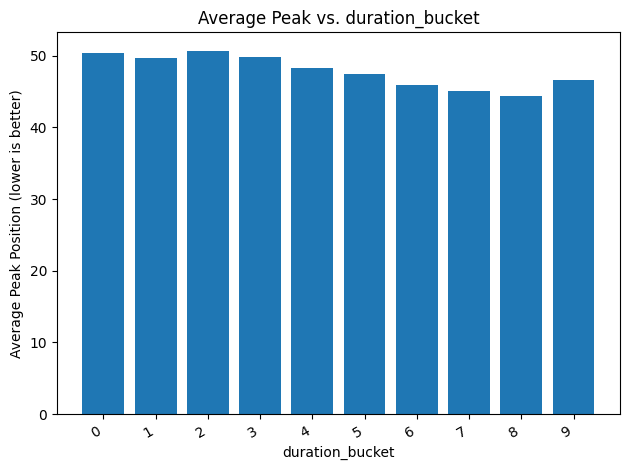

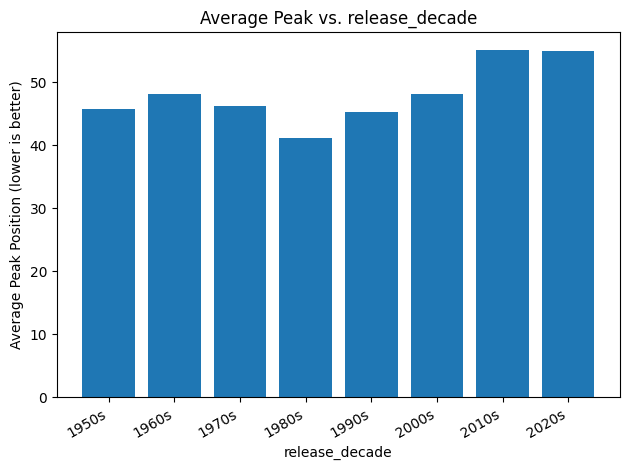

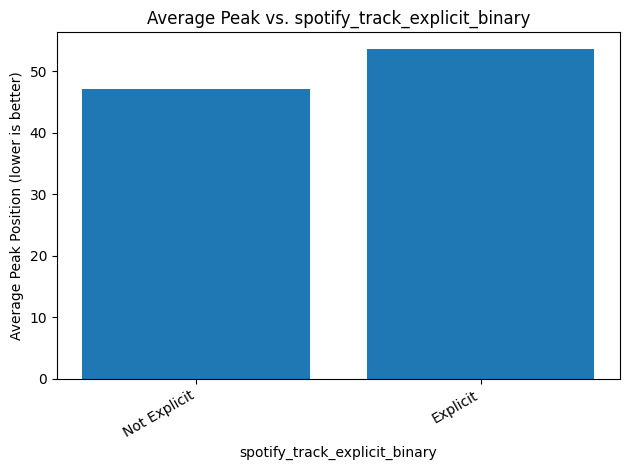

In [ ]:
# replot charts of Avg Peak vs engineered features

numeric_features_new = [
    "dance_x_energy",
    "dance_x_valence",
    "acoustic_energy_interaction", # (1 - acousticness) * energy
    "tempo_deviation_120", # abs(tempo - 120)
]

categorical_features_new = [
    "duration_bucket",
    "release_decade",
    "spotify_track_explicit_binary",
]

con = duckdb.connect()
con.register("df", df_model_6)

# numeric charts
for col in numeric_features_new:
    if col not in df_model_6.columns:
        print(f"[skip] numeric feature not found: {col}")
        continue

    sql = f"""
    WITH base AS (
      SELECT
        CAST("Peak Position" AS DOUBLE) AS peak_pos,
        TRY_CAST({col} AS DOUBLE)       AS x
      FROM df
      WHERE "Peak Position" IS NOT NULL
    ),
    ranked AS (
      SELECT
        peak_pos, x,
        NTILE(10) OVER (ORDER BY x) AS qbin
      FROM base
      WHERE x IS NOT NULL AND isfinite(x)
    ),
    summ AS (
      SELECT
        qbin,
        MIN(x) AS bin_min,
        MAX(x) AS bin_max,
        AVG(peak_pos) AS avg_peak_position,
        COUNT(*)      AS n
      FROM ranked
      GROUP BY qbin
      ORDER BY qbin
    )
    SELECT * FROM summ;
    """
    out = con.execute(sql).df()
    if out.empty:
        print(f"[skip] no rows after filtering for {col}")
        continue

    labels = (out["bin_min"].round(3).astype(str) + "–" + out["bin_max"].round(3).astype(str))

    plt.figure()
    plt.bar(labels, out["avg_peak_position"])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel(f"{col} (deciles)")
    plt.ylabel("Average Peak Position (lower is better)")
    plt.title(f"Average Peak vs. {col}")
    plt.tight_layout()
    plt.show()

# categorical charts
for col in categorical_features_new:
    if col not in df_model_6.columns:
        print(f"[skip] categorical feature not found: {col}")
        continue

    if col == "release_decade":
        cast_expr = f"CAST({col} AS INT)"
    elif col == "spotify_track_explicit_binary":
        cast_expr = f"CAST({col} AS INT)"
    else:
        cast_expr = f"CAST({col} AS VARCHAR)"

    sql = f"""
    WITH base AS (
      SELECT
        {cast_expr} AS k,
        CAST("Peak Position" AS DOUBLE) AS peak_pos
      FROM df
      WHERE "Peak Position" IS NOT NULL
        AND {col} IS NOT NULL
    )
    SELECT
      k,
      AVG(peak_pos) AS avg_peak_position,
      COUNT(*)      AS n
    FROM base
    GROUP BY k
    ORDER BY k;
    """

    out = con.execute(sql).df()
    if out.empty:
        print(f"[skip] no rows after filtering for {col}")
        continue

    # x labels
    if col == "release_decade":
        try:
            x = out["k"].astype(int).astype(str) + "s"
        except Exception:
            x = out["k"].astype(str)
    elif col == "spotify_track_explicit_binary":
        x = out["k"].map({0: "Not Explicit", 1: "Explicit"}).fillna(out["k"].astype(str))
    else:
        x = out["k"].astype(str)

    plt.figure()
    plt.bar(x, out["avg_peak_position"])
    plt.xticks(rotation=30, ha="right")
    plt.xlabel(col)
    plt.ylabel("Average Peak Position (lower is better)")
    plt.title(f"Average Peak vs. {col}")
    plt.tight_layout()
    plt.show()



In [ ]:
# popularity normalizations

# year z-score
mu_y = df_model_6.groupby("release_year")["spotify_track_popularity"].transform("mean")
sd_y = df_model_6.groupby("release_year")["spotify_track_popularity"].transform("std").replace(0, np.nan)
df_model_6["pop_z_year"] = (df_model_6["spotify_track_popularity"] - mu_y) / sd_y

# genre × year z-score
mu_gy = (df_model_6.groupby(["grouped_genre","release_year"])["spotify_track_popularity"].transform("mean"))

sd_gy = (df_model_6.groupby(["grouped_genre","release_year"])["spotify_track_popularity"].transform("std")).replace(0, np.nan)

df_model_6["pop_z_genre_year"] = (df_model_6["spotify_track_popularity"] - mu_gy) / sd_gy

# if sd is NaN use year z
df_model_6["pop_z_genre_year"] = df_model_6["pop_z_genre_year"].fillna(df_model_6["pop_z_year"])

# popularity freq buckets
df_model_6["pop_decile"] = pd.qcut(df_model_6["spotify_track_popularity"], 10, labels=False, duplicates="drop")

# interactions
df_model_6["pop_x_dance"] = df_model_6["spotify_track_popularity"]*df_model_6["danceability"]
df_model_6["pop_x_energy"] = df_model_6["spotify_track_popularity"]*df_model_6["energy"]
df_model_6["pop_x_valence"] = df_model_6["spotify_track_popularity"]*df_model_6["valence"]

# "radio energy" = dance*energy, then interact with popularity
df_model_6["dance_x_energy"]  = df_model_6["danceability"] * df_model_6["energy"]
df_model_6["pop_x_danceEnergy"] = df_model_6["spotify_track_popularity"] * df_model_6["dance_x_energy"]

df_model_6.head()

,WeekID,Week Position,Song,Performer,Previous Week Position,Peak Position,Weeks on Chart,spotify_genre,spotify_track_duration_ms,spotify_track_explicit,...,release_decade,spotify_track_explicit_binary,genre_decade_interaction,pop_z_year,pop_z_genre_year,pop_decile,pop_x_dance,pop_x_energy,pop_x_valence,pop_x_danceEnergy
0,6/16/1990,54,"""B"" Girls",Young And Restless,55.0,54,7,[],242106.0,False,...,1990,0,other_1990,-1.051685,-0.617909,2,12.30,9.940,15.380,6.11310
1,4/28/1973,35,"""Cherry Cherry"" from Hot August Night",Neil Diamond,36.0,35,7,"['adult standards', 'brill building pop', 'fol...",443320.0,False,...,1970,0,adult_standards_1970,-0.900902,-1.095496,1,5.44,15.168,9.664,5.15712
2,12/1/2001,23,#1,Nelly,30.0,23,7,"['dance pop', 'hip hop', 'pop', 'pop rap', 'ra...",198760.0,True,...,2000,1,pop_2000,0.001821,-0.309883,6,39.60,30.000,23.150,23.76000
3,12/2/1978,82,#1 Dee Jay,Goody Goody,84.0,82,3,['pop rap'],206106.0,False,...,1970,0,hiphop_1970,-1.918162,-0.707107,0,0.00,0.000,0.000,0.00000
4,2/8/1975,13,#9 Dream,John Lennon,17.0,13,8,"['album rock', 'classic rock', 'folk rock', 'm...",286813.0,False,...,1970,0,rock_1970,1.242803,0.643062,6,22.33,32.835,26.290,13.33101


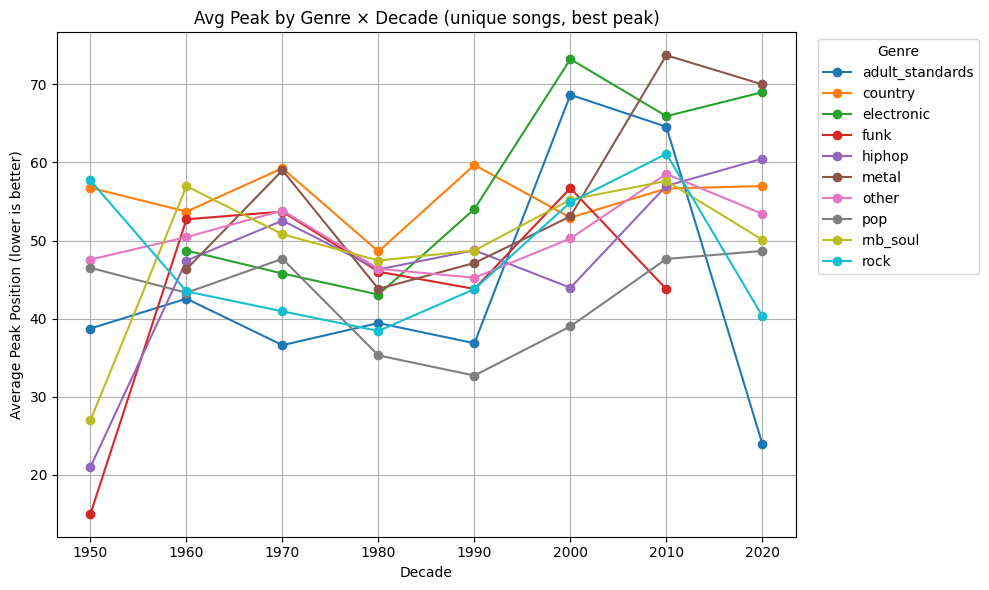

In [ ]:
con = duckdb.connect(); con.register("df", df_model_6)

TOP_N_GENRES = 10

sql = f"""
WITH base AS (
  SELECT
    Song,
    grouped_genre,
    CAST("Peak Position" AS DOUBLE) AS peak_pos,
    TRY_CAST(release_year AS INT)    AS release_year
  FROM df
  WHERE grouped_genre IS NOT NULL
    AND "Peak Position" IS NOT NULL
    AND release_year IS NOT NULL
),
song_best AS (
  -- one row per song: best (lowest) peak and earliest release_year (tie-breaker)
  SELECT
    Song,
    grouped_genre,
    MIN(peak_pos)     AS min_peak,
    MIN(release_year) AS min_release_year
  FROM base
  GROUP BY Song, grouped_genre
),
with_decade AS (
  SELECT
    grouped_genre,
    CAST(FLOOR(min_release_year / 10.0) * 10 AS INT) AS decade,  -- <-- fixed decade calc
    min_peak
  FROM song_best
),
genre_totals AS (
  SELECT grouped_genre, COUNT(*) AS total_songs
  FROM with_decade
  GROUP BY grouped_genre
),
filtered AS (
  -- keep only top-N genres by total volume
  SELECT w.*
  FROM with_decade w
  JOIN (
    SELECT grouped_genre
    FROM genre_totals
    ORDER BY total_songs DESC
    LIMIT {TOP_N_GENRES}
  ) t USING (grouped_genre)
),
agg AS (
  SELECT
    grouped_genre,
    decade,
    AVG(min_peak) AS avg_peak_position,
    COUNT(*)      AS num_songs
  FROM filtered
  GROUP BY grouped_genre, decade
)
SELECT * FROM agg
ORDER BY grouped_genre, decade;
"""

gdec = duckdb.execute(sql).df()

# pivot and plot trends
pivot = gdec.pivot(index="decade", columns="grouped_genre", values="avg_peak_position").sort_index()
plt.figure(figsize=(10,6))
for col in pivot.columns:
    plt.plot(pivot.index.astype(int), pivot[col], marker="o", label=col)
plt.xlabel("Decade")
plt.ylabel("Average Peak Position (lower is better)")
plt.title("Avg Peak by Genre × Decade (unique songs, best peak)")
plt.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


# Final Evaluation

In [ ]:
# choosing feature columns to use to train the model, including the interaction vars

numeric_features2 = [
    "spotify_track_duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
    "spotify_track_popularity",
    "release_year",
    "prior_song_count",
    "prior_top10_count",
    "prior_best_peak",
    "prior_avg_peak",
    "dance_x_energy",
    "dance_x_valence",
    "acoustic_energy_interaction",
    "tempo_deviation_120",
    "pop_z_year",
    "pop_z_genre_year",
    "pop_x_dance",
    "pop_x_energy",
    "pop_x_valence",
    "pop_x_danceEnergy",
]

categorical_features2 = [
    "grouped_genre",
    "main_artist_single_manually_mapped",
    "duration_bucket",
    "release_decade",
    "spotify_track_explicit_binary",
    "genre_decade_interaction",
    "pop_decile",
]

# defne target and features total
target = "chart_class"
features = numeric_features2 + categorical_features2
# store clean data
data6 = df_model_6[features + [target]].dropna()

# define variables
X6 = data6[features]
y6 = data6[target].astype(int)

In [ ]:
# re-preprocessing (again) & logistic regression (new features)

# preprocess for numeric cols:
numeric_trans = Pipeline(steps=[("scaler", StandardScaler())]) # this will apply StandardScaler() to numeric cols
# when .fit() -> compute mean & stdev per numeric feature, when .transform() -> standardizes

# preprocess for categorical cols:
categorical_trans = OneHotEncoder(handle_unknown="ignore") # one hot encode cat features
# ignore unseen cats

# combine w col transformer:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_trans, numeric_features2), # apply numeric transformer ^ to numeric features
        ("cat", categorical_trans, categorical_features2) # apply cat transformer ^ to cat features
    ]
)

# logistic regression classifier:
logistic = OneVsRestClassifier(LogisticRegression(solver="lbfgs", max_iter=1000))

# model defn:
model6 = Pipeline(steps=[("preprocess", preprocess), ("clf", logistic)]) # first preprocess/transform features, then fit logistic reg.

In [ ]:
# evaluation:
# 80/20 train/test split

result6 = train_test_split(X6, y6, test_size=0.2, stratify=y6, random_state=0)
# 20% test size, 80% training data
# stratify=y -> test set should keep same class proportions as original data (class 1,2,3)
# no randomness fo rreproducability

# defn split result outputs:
X6_train = result6[0]
X6_test = result6[1]
y6_train = result6[2]
y6_test = result6[3]

# setup 5-fold cross validation:
cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
# shuffle rows to prevent biases
# no randomness

cross_val_scores6 = cross_val_score(model6, X6_train, y6_train, cv=cross_val, scoring="accuracy")
# split training into 5 folds, trains model on 4 folds and tests accuracy on remaining fold

print("5-fold cross val accuracy: {:.4f} +- {:.3}".format(cross_val_scores6.mean(), cross_val_scores6.std()))

5-fold cross val accuracy: 0.6549 +- 0.00806


In [ ]:
model6.fit(X6_train, y6_train)

y6_pred = model6.predict(X6_test)

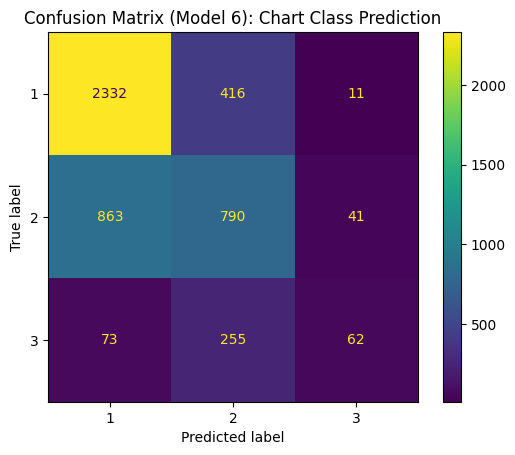

In [ ]:
# confusion matrix

labels = sorted(y6.unique().tolist()) # sort class vals

conf_m = confusion_matrix(y6_test, y6_pred, labels=labels) # use test and predicted vals
display = ConfusionMatrixDisplay(confusion_matrix=conf_m, display_labels=labels)
display.plot(values_format="d")
plt.title("Confusion Matrix (Model 6): Chart Class Prediction")
plt.show()

In [ ]:
# random forest

rf_cv_scores6 = cross_val_score(rf_model, X6_train, y6_train, cv=cross_val, scoring="accuracy")

print("RF 5-fold CV accuracy (model 1): {:.4f} +- {:.3f}".format(rf_cv_scores6.mean(), rf_cv_scores6.std()))

RF 5-fold CV accuracy (model 1): 0.6364 +- 0.005


In [ ]:
# coefficient interpretation (model 6)
###(OpenAI, 2025)

interpret_coef(fitted=model6, split="Model 6", num_feats=numeric_features2, cat_feats=categorical_features2, class_names=split4_labels) # uses same split as model 4

Coefficient interpretation for: Model 6

Class 1 (41-100)

Features that INCREASE odds of this class:
cat__grouped_genre_latin                  0.630
num__release_year                         0.540
cat__grouped_genre_world                  0.443
cat__grouped_genre_jazz                   0.391
cat__grouped_genre_reggae                 0.343
cat__grouped_genre_metal                  0.337
cat__grouped_genre_blues                  0.333
num__pop_x_danceEnergy                    0.232
cat__grouped_genre_alternative            0.231
cat__grouped_genre_country                0.215

Features that DECREASE odds of this class:
num__pop_z_genre_year                    -0.627
cat__grouped_genre_adult_standards       -0.580
cat__grouped_genre_pop                   -0.493
num__pop_z_year                          -0.492
cat__grouped_genre_other                 -0.420
num__pop_x_dance                         -0.384
cat__grouped_genre_soundtrack            -0.373
cat__grouped_genre_folk_acoustic      

# Refrences

OpenAI. (2025). ChatGPT (Nov 26 version) [Large language model]. https://chat.openai.com/chat